<span style="font-size: 30px">Amerihome (Western Alliance) - Financial Engineer Project</span>

<span style="font-size: 30px">John Paul Dulay, Claremont Graduate University</span>

<span style="font-size: 30px">05/02/2025</span>

==========================================================


<span style="font-size: 25px">Task: Given datasets of Treasury Yields and 30-Yr Fixed Mortgage Index -</span>

(1) Perform data pre-processing 

(2) Exploratory Data Analysis

(3) Deploy two (x2) methods to forecast 30-Yr Fixed Mortgage Index based on Treasury Yields

(4) Compare forecast accuracy between the methods

==========================================================

<span style="font-size: 20px">Preliminaries</span>

In [71]:
# libraries for data analytics
import pandas as pd
import numpy as np
import scipy.stats as stats

# libraries for visualizations
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# libraries for time-series analytics
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf
from pmdarima import ARIMA

# others
from itertools import product
import warnings
from IPython.display import display

<span style="font-size: 20px">(1) Data Pre-processing/Cleaning</span>

- Follow SR11-7 Conceptual Soundness Evaluation guidelines

In [3]:
# import the csv files and parse dates to datetime objects
yield_curve_df = pd.read_csv(r"C:\Users\jpkdu\Documents\Amerihome - Financial Engr Project\daily_treasury_yield_curve_data.csv", parse_dates=['Date'])
mortgage_index_df = pd.read_csv(r"C:\Users\jpkdu\Documents\Amerihome - Financial Engr Project\OBMMIC30YF_data.csv", parse_dates=['DATE'])

# set date column as index
yield_curve_df = yield_curve_df.set_index('Date')
mortgage_index_df = mortgage_index_df.set_index('DATE')

# see sample of the datasets
display(yield_curve_df.head())
display(mortgage_index_df.head())

,1 Mo,2 Mo,3 Mo,6 Mo,1 Yr,2 Yr,3 Yr,5 Yr,7 Yr,10 Yr,20 Yr,30 Yr
Date,,,,,,,,,,,,
2024-10-08,4.96,4.85,4.75,4.44,4.21,3.98,3.86,3.86,3.94,4.04,4.38,4.32
2024-10-07,5.00,4.87,4.77,4.45,4.24,3.99,3.89,3.86,3.92,4.03,4.37,4.30
2024-10-04,5.01,4.88,4.73,4.45,4.20,3.93,3.84,3.81,3.88,3.98,4.33,4.26
2024-10-03,4.99,4.85,4.68,4.37,4.02,3.70,3.62,3.62,3.71,3.85,4.24,4.18
2024-10-02,4.92,4.83,4.69,4.36,3.97,3.63,3.54,3.55,3.65,3.79,4.19,4.14


,OBMMIC30YF
DATE,
2019-12-27,3.933
2019-12-30,3.952
2019-12-31,3.927
2020-01-01,.
2020-01-02,3.914


In [4]:
# shows summaries of the dataframes
display(yield_curve_df.info())

display(mortgage_index_df.info())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1195 entries, 2024-10-08 to 2020-01-02
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   1 Mo    1195 non-null   float64
 1   2 Mo    1195 non-null   float64
 2   3 Mo    1195 non-null   float64
 3   6 Mo    1195 non-null   float64
 4   1 Yr    1195 non-null   float64
 5   2 Yr    1195 non-null   float64
 6   3 Yr    1195 non-null   float64
 7   5 Yr    1195 non-null   float64
 8   7 Yr    1195 non-null   float64
 9   10 Yr   1195 non-null   float64
 10  20 Yr   1195 non-null   float64
 11  30 Yr   1195 non-null   float64
dtypes: float64(12)
memory usage: 121.4 KB


None

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1247 entries, 2019-12-27 to 2024-10-07
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   OBMMIC30YF  1247 non-null   object
dtypes: object(1)
memory usage: 19.5+ KB


None

seems like the mortgage index dataframe has vague data objects, will need to fix this

In [5]:
# checks for inconsistent data types for each column
display(yield_curve_df.map(type).nunique())

display(mortgage_index_df.map(type).nunique())

1 Mo     1
2 Mo     1
3 Mo     1
6 Mo     1
1 Yr     1
2 Yr     1
3 Yr     1
5 Yr     1
7 Yr     1
10 Yr    1
20 Yr    1
30 Yr    1
dtype: int64

OBMMIC30YF    1
dtype: int64

In [6]:
# since mortgage_index_df shows "object" dtype, convert it to numerical (float) and flag non-numerics as NaN
mortgage_index_df = mortgage_index_df.apply(pd.to_numeric, errors='coerce')
# check how many flagged NaNs
mortgage_index_df.isnull().sum()


OBMMIC30YF    52
dtype: int64

flagged 52 non-numeric datapoints in the mortgage index dataframe, do the same checks in yield curve dataframe:

In [7]:
# check yield_curve_df for flagged NaNs
yield_curve_df = yield_curve_df.apply(pd.to_numeric, errors='coerce')
yield_curve_df.isnull().sum()


1 Mo     0
2 Mo     0
3 Mo     0
6 Mo     0
1 Yr     0
2 Yr     0
3 Yr     0
5 Yr     0
7 Yr     0
10 Yr    0
20 Yr    0
30 Yr    0
dtype: int64

handle missing data

In [8]:
# obtain the indices with NaN in mortgage index df
isNaN_index = mortgage_index_df[ mortgage_index_df['OBMMIC30YF'].isnull() == True ].index

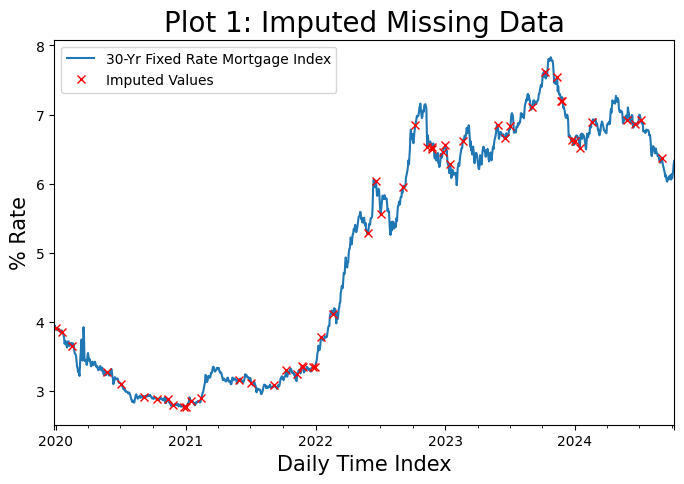

In [9]:
# interpolate/impute missing data (NaN values) in mortgage_index_df using polynomial method
mortgage_index_df = mortgage_index_df.interpolate(method='polynomial', order=2).round(3)

# visualize imputed values
fig = plt.figure(figsize=(8,5))
mortgage_index_df['OBMMIC30YF'].plot(label='30-Yr Fixed Rate Mortgage Index')
mortgage_index_df['OBMMIC30YF'].loc[isNaN_index].plot(style='x', color='red', label='Imputed Values')

plt.ylabel('% Rate', fontsize=15)
plt.xlabel('Daily Time Index', fontsize=15)
plt.title(f'Plot 1: Imputed Missing Data', fontsize=20)

plt.legend()
plt.show()


In [10]:
# consolidate yield_curve and mortgage_index into a single df
# note that ~52 days worth of mortgage index data is lost in the process 
df = pd.concat([yield_curve_df, mortgage_index_df], axis=1).dropna()

df

,1 Mo,2 Mo,3 Mo,6 Mo,1 Yr,2 Yr,3 Yr,5 Yr,7 Yr,10 Yr,20 Yr,30 Yr,OBMMIC30YF
2020-01-02,1.53,1.55,1.54,1.57,1.56,1.58,1.59,1.67,1.79,1.88,2.19,2.33,3.914
2020-01-03,1.52,1.55,1.52,1.55,1.55,1.53,1.54,1.59,1.71,1.80,2.11,2.26,3.889
2020-01-06,1.54,1.54,1.56,1.56,1.54,1.54,1.56,1.61,1.72,1.81,2.13,2.28,3.882
2020-01-07,1.52,1.53,1.54,1.56,1.53,1.54,1.55,1.62,1.74,1.83,2.16,2.31,3.882
2020-01-08,1.50,1.53,1.54,1.56,1.55,1.58,1.61,1.67,1.78,1.87,2.21,2.35,3.892
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-10-01,4.96,4.87,4.71,4.36,3.96,3.61,3.52,3.51,3.60,3.74,4.14,4.08,6.082
2024-10-02,4.92,4.83,4.69,4.36,3.97,3.63,3.54,3.55,3.65,3.79,4.19,4.14,6.132
2024-10-03,4.99,4.85,4.68,4.37,4.02,3.70,3.62,3.62,3.71,3.85,4.24,4.18,6.182
2024-10-04,5.01,4.88,4.73,4.45,4.20,3.93,3.84,3.81,3.88,3.98,4.33,4.26,6.275


handling temporal correlations among treasury yields

In [11]:
# deploying PCA to handle correlations among treasury yields
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# standardizing
scaler = StandardScaler() 
# alternative: ( yield_curve_df - yield_curve_df.mean() ) / yield_curve_df.std() 
yield_curve_scaled_df = pd.DataFrame(data=scaler.fit_transform(yield_curve_df.loc[df.index]), columns=yield_curve_df.columns, index=df.index)

yield_curve_scaled_df.head()

,1 Mo,2 Mo,3 Mo,6 Mo,1 Yr,2 Yr,3 Yr,5 Yr,7 Yr,10 Yr,20 Yr,30 Yr
2020-01-02,-0.356208,-0.375498,-0.396115,-0.419545,-0.434182,-0.432825,-0.448838,-0.473302,-0.506327,-0.530308,-0.630464,-0.557097
2020-01-03,-0.360367,-0.375498,-0.404435,-0.428031,-0.438683,-0.458111,-0.476294,-0.522911,-0.560136,-0.588374,-0.692548,-0.617763
2020-01-06,-0.352048,-0.379649,-0.387796,-0.423788,-0.443185,-0.453054,-0.465311,-0.510509,-0.553409,-0.581116,-0.677027,-0.600430
2020-01-07,-0.360367,-0.383801,-0.396115,-0.423788,-0.447686,-0.453054,-0.470803,-0.504308,-0.539957,-0.566599,-0.653746,-0.574430
2020-01-08,-0.368686,-0.383801,-0.396115,-0.423788,-0.438683,-0.432825,-0.437855,-0.473302,-0.513053,-0.537566,-0.614943,-0.539764


In [12]:
from sklearn.preprocessing import MinMaxScaler

# normalizing - I think not recommended since the yield curves have relatively uniform values
min_max_scaler = MinMaxScaler(feature_range=(0,1))

yield_curve_scaled_minmax_df = pd.DataFrame(data=min_max_scaler.fit_transform(yield_curve_df.loc[df.index]), columns=yield_curve_df.columns, index=df.index)

yield_curve_scaled_minmax_df.head()

,1 Mo,2 Mo,3 Mo,6 Mo,1 Yr,2 Yr,3 Yr,5 Yr,7 Yr,10 Yr,20 Yr,30 Yr
2020-01-02,0.254153,0.276292,0.273535,0.277281,0.278899,0.292157,0.302231,0.310924,0.308190,0.304933,0.297968,0.325243
2020-01-03,0.252492,0.276292,0.269982,0.273703,0.277064,0.282353,0.292089,0.294118,0.290948,0.286996,0.279910,0.308252
2020-01-06,0.255814,0.274510,0.277087,0.275492,0.275229,0.284314,0.296146,0.298319,0.293103,0.289238,0.284424,0.313107
2020-01-07,0.252492,0.272727,0.273535,0.275492,0.273394,0.284314,0.294118,0.300420,0.297414,0.293722,0.291196,0.320388
2020-01-08,0.249169,0.272727,0.273535,0.275492,0.277064,0.292157,0.306288,0.310924,0.306034,0.302691,0.302483,0.330097


In [13]:
# PCA result; if single column, then PC1 result
pca = PCA(n_components=0.95)
principal_components = pca.fit_transform(yield_curve_scaled_df)
yield_curve_pca_df = pd.DataFrame(data=principal_components, index=df.index, columns=['PCA'])
yield_curve_pca_df.head()

,PCA
2020-01-02,-1.605818
2020-01-03,-1.710604
2020-01-06,-1.682966
2020-01-07,-1.667708
2020-01-08,-1.605668


<Axes: xlabel='Date'>

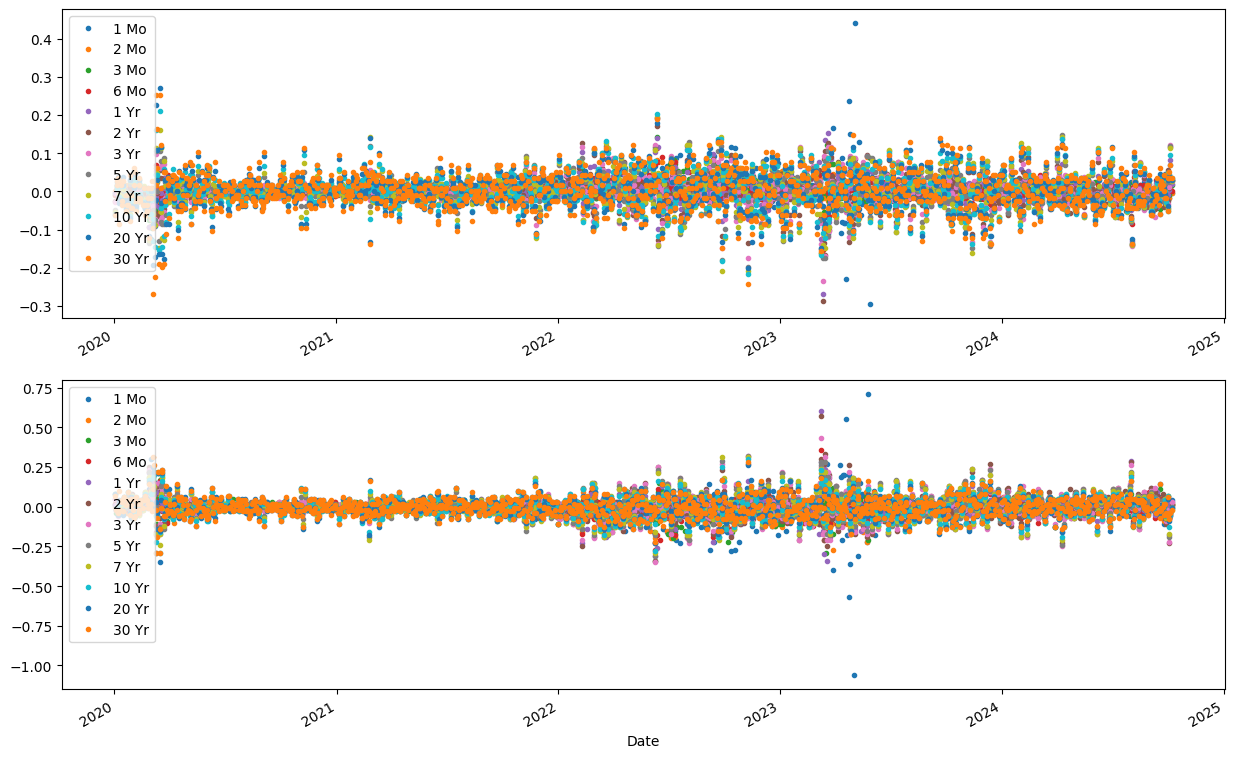

In [14]:
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1) 

yield_curve_scaled_df.diff(1).dropna().plot(style='.', figsize=(15,10), ax=ax1) 
yield_curve_df.diff(1).dropna().plot(style='.', figsize=(15,10), ax=ax2) 

In [28]:
for x in yield_curve_df.columns:
    print(x)
    adf_test(yield_curve_df.diff(1).dropna()[x])

1 Mo
Results of ADF Test: 
Test Statistic                -7.699804e+00
p-value                        1.348756e-11
#Lags Used                     1.800000e+01
Number of Observations Used    1.175000e+03
Critical Value (1%)           -3.435928e+00
Critical Value (5%)           -2.864003e+00
Critical Value (10%)          -2.568081e+00
dtype: float64
@ Critical Value (1%) ---> Reject Null Hypothesis = Time-series is Stationary
@ Critical Value (5%) ---> Reject Null Hypothesis = Time-series is Stationary
@ Critical Value (10%) ---> Reject Null Hypothesis = Time-series is Stationary
2 Mo
Results of ADF Test: 
Test Statistic                -6.301010e+00
p-value                        3.412239e-08
#Lags Used                     1.600000e+01
Number of Observations Used    1.177000e+03
Critical Value (1%)           -3.435918e+00
Critical Value (5%)           -2.863999e+00
Critical Value (10%)          -2.568079e+00
dtype: float64
@ Critical Value (1%) ---> Reject Null Hypothesis = Time-series i

In [29]:
for x in yield_curve_df.columns:
    print(x)
    kpss_test(yield_curve_df.diff(1).dropna()[x])

1 Mo
Results of KPSS Test:
Test Statistic            0.428730
p-value                   0.064772
Lags Used                10.000000
Critical Value (10%)      0.347000
Critical Value (5%)       0.463000
Critical Value (2.5%)     0.574000
Critical Value (1%)       0.739000
dtype: float64
@ Critical Value (10%) ---> Reject Null Hypothesis = Time-series is Not Stationary
@ Critical Value (5%) ---> Failed to Reject Null Hypothesis = Time-series is [Trend] Stationary
@ Critical Value (2%) ---> Failed to Reject Null Hypothesis = Time-series is [Trend] Stationary
@ Critical Value (1%) ---> Failed to Reject Null Hypothesis = Time-series is [Trend] Stationary
2 Mo
Results of KPSS Test:
Test Statistic            0.761111
p-value                   0.010000
Lags Used                15.000000
Critical Value (10%)      0.347000
Critical Value (5%)       0.463000
Critical Value (2.5%)     0.574000
Critical Value (1%)       0.739000
dtype: float64
@ Critical Value (10%) ---> Reject Null Hypothesis = Ti

C:\Users\jpkdu\AppData\Local\Temp\ipykernel_18156\1449836856.py:11: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.


C:\Users\jpkdu\AppData\Local\Temp\ipykernel_18156\1449836856.py:11: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.


C:\Users\jpkdu\AppData\Local\Temp\ipykernel_18156\1449836856.py:11: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.


C:\Users\jpkdu\AppData\Local\Temp\ipykernel_18156\1449836856.py:11: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.


C:\Users\jpkdu\AppData\Local\Temp\ipykernel_18156\14

In [418]:
# NEXT STEPS - CONTINUE WITH GRANGER CAUSALITY

<span style="font-size: 20px">(2) Exploratory Data Analysis</span>

In [16]:
# show summary of descriptive statistics of the time-series
df.describe()

,1 Mo,2 Mo,3 Mo,6 Mo,1 Yr,2 Yr,3 Yr,5 Yr,7 Yr,10 Yr,20 Yr,30 Yr,OBMMIC30YF
count,1194.000000,1194.000000,1194.000000,1194.000000,1194.000000,1194.000000,1194.000000,1194.000000,1194.000000,1194.000000,1194.000000,1194.000000,1194.000000
mean,2.386390,2.454472,2.492286,2.558769,2.524548,2.435854,2.407379,2.433241,2.542781,2.610628,3.002404,2.972814,4.994952
std,2.405197,2.409739,2.405071,2.357751,2.222460,1.978196,1.821863,1.613265,1.487371,1.378320,1.289120,1.154347,1.719090
min,0.000000,0.000000,0.000000,0.020000,0.040000,0.090000,0.100000,0.190000,0.360000,0.520000,0.870000,0.990000,2.770000
25%,0.080000,0.090000,0.090000,0.110000,0.130000,0.200000,0.350000,0.800000,1.130000,1.370000,1.870000,1.920000,3.200500
50%,1.525000,1.560000,1.570000,1.570000,2.080000,2.660000,2.820000,2.870000,2.870000,2.825000,3.220000,3.010000,5.408500
75%,5.377500,5.330000,5.340000,5.190000,4.830000,4.430000,4.210000,3.990000,3.950000,3.890000,4.190000,4.047500,6.689750
max,6.020000,5.610000,5.630000,5.610000,5.490000,5.190000,5.030000,4.950000,5.000000,4.980000,5.300000,5.110000,7.830000


In [17]:
# check for correlations
np.log(df.diff(1)).dropna().corr()

c:\Users\jpkdu\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: divide by zero encountered in log
  result = func(self.values, **kwargs)
c:\Users\jpkdu\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)


,1 Mo,2 Mo,3 Mo,6 Mo,1 Yr,2 Yr,3 Yr,5 Yr,7 Yr,10 Yr,20 Yr,30 Yr,OBMMIC30YF
1 Mo,1.000000,0.667665,0.264765,0.292293,0.311446,0.243100,0.218296,0.224413,0.138220,0.087887,0.017362,-0.001876,0.098550
2 Mo,0.667665,1.000000,0.525350,0.468118,0.443459,0.289677,0.361774,0.357991,0.339978,0.302605,0.200496,0.104257,0.290364
3 Mo,0.264765,0.525350,1.000000,0.702748,0.499261,0.284866,0.331832,0.298053,0.349925,0.332953,0.299490,0.241877,0.376511
6 Mo,0.292293,0.468118,0.702748,1.000000,0.718766,0.522085,0.515930,0.424697,0.434855,0.371384,0.284023,0.214519,0.406689
1 Yr,0.311446,0.443459,0.499261,0.718766,1.000000,0.706630,0.657765,0.555440,0.566267,0.487778,0.301123,0.273284,0.429812
2 Yr,0.243100,0.289677,0.284866,0.522085,0.706630,1.000000,0.845845,0.768563,0.670890,0.580908,0.347190,0.303202,0.425231
3 Yr,0.218296,0.361774,0.331832,0.515930,0.657765,0.845845,1.000000,0.858386,0.817591,0.716279,0.481106,0.429525,0.562622
5 Yr,0.224413,0.357991,0.298053,0.424697,0.555440,0.768563,0.858386,1.000000,0.902661,0.843549,0.615220,0.558833,0.560815
7 Yr,0.138220,0.339978,0.349925,0.434855,0.566267,0.670890,0.817591,0.902661,1.000000,0.941957,0.733578,0.675432,0.681973
10 Yr,0.087887,0.302605,0.332953,0.371384,0.487778,0.580908,0.716279,0.843549,0.941957,1.000000,0.839848,0.779270,0.658417


Visualizations

In [18]:
# Plot all columns using the DataFrame index as x-axis
fig = px.line(df, x=df.index, y=df.columns, width=1000, height=500)
fig.update_layout(
    xaxis_title="Daily Time Index",
    yaxis_title="% Rate",
    legend_title_text="Legend",
    title={'text':'Plot 2: Treasuries and 30-Yr Fixed Rate Conforming Morgage Index',
           'font': dict(size=23)} 
)

fig.update_xaxes(title_font=dict(size=20))
fig.update_yaxes(title_font=dict(size=20))

fig.show()

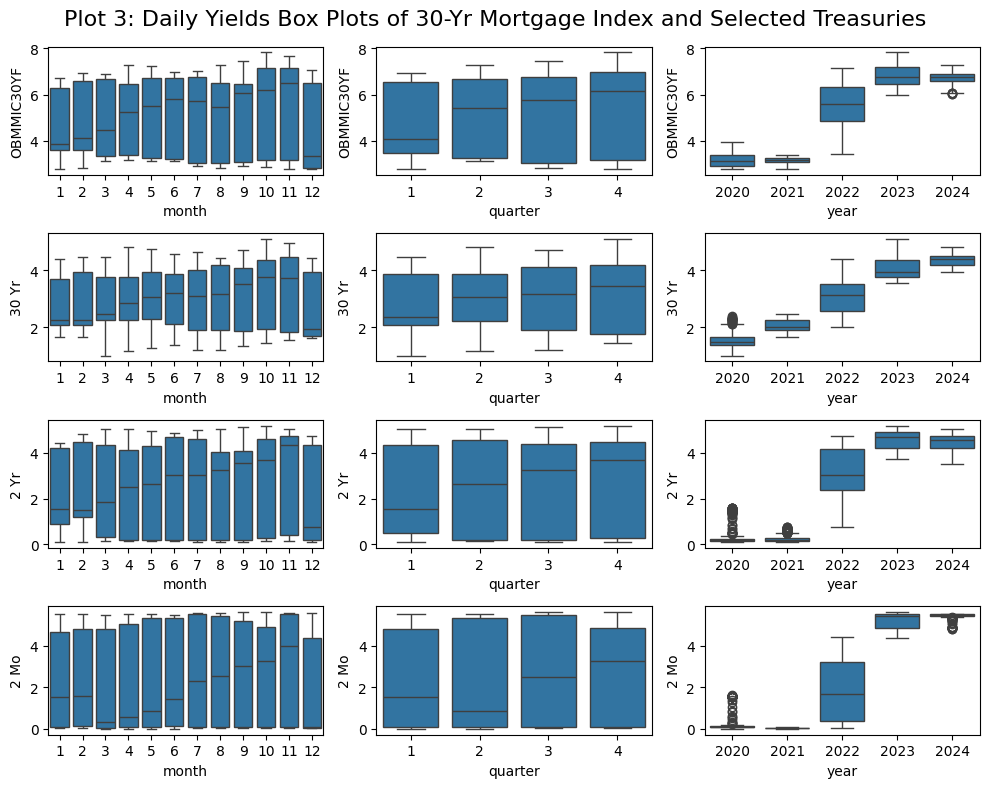

In [19]:
# Box-plot visualizations of monthly datapoints to consolidated time periods

# create monthly, quarterly, yearly features for visualization
def create_features(df):

    df = df.copy()
    df['quarter'] = pd.to_datetime(df.index).quarter
    df['month'] = pd.to_datetime(df.index).month
    df['year'] = pd.to_datetime(df.index).year
    df['week'] = pd.to_datetime(df.index).isocalendar().week

    return df

mortg_index_viz_df = create_features(df[['OBMMIC30YF']]).copy(deep=True) 
yr30_viz_df = create_features(df[['30 Yr']]).copy(deep=True) 
yr2_viz_df = create_features(df[['2 Yr']]).copy(deep=True) 
mo2_viz_df = create_features(df[['2 Mo']]).copy(deep=True) 

# build box plots
fig, axes = plt.subplots(ncols=3, nrows=4, figsize=(10,8))
axes_flat = axes.flatten()
ax_11, ax_12, ax_13, ax_21, ax_22, ax_23, ax_31, ax_32, ax_33, ax_41, ax_42, ax_43 = axes_flat

# 30-Yr Mortgage Index
sns.boxplot(data=mortg_index_viz_df, x='month', y='OBMMIC30YF', ax=ax_11)
sns.boxplot(data=mortg_index_viz_df, x='quarter', y='OBMMIC30YF', ax=ax_12)
sns.boxplot(data=mortg_index_viz_df, x='year', y='OBMMIC30YF', ax=ax_13)

# 30yr
sns.boxplot(data=yr30_viz_df, x='month', y='30 Yr', ax=ax_21)
sns.boxplot(data=yr30_viz_df, x='quarter', y='30 Yr', ax=ax_22)
sns.boxplot(data=yr30_viz_df, x='year', y='30 Yr', ax=ax_23)

# 2yr
sns.boxplot(data=yr2_viz_df, x='month', y='2 Yr', ax=ax_31)
sns.boxplot(data=yr2_viz_df, x='quarter', y='2 Yr', ax=ax_32)
sns.boxplot(data=yr2_viz_df, x='year', y='2 Yr', ax=ax_33)

# 2mo
sns.boxplot(data=mo2_viz_df, x='month', y='2 Mo', ax=ax_41)
sns.boxplot(data=mo2_viz_df, x='quarter', y='2 Mo', ax=ax_42)
sns.boxplot(data=mo2_viz_df, x='year', y='2 Mo', ax=ax_43)

fig.suptitle("Plot 3: Daily Yields Box Plots of 30-Yr Mortgage Index and Selected Treasuries", fontsize=16)
plt.tight_layout()
plt.show()


On Plot 3 above, in the yearly indices, it is observed that the rise in yields from 2022 onwards across short-term & long-term treasuries as well as the 30-Yr Mortgage Index. This can be explained by the FED's aggressive interest rate hikes that started in 2022 to combat post-Covid inflation. 

*

In [20]:
# visualize annual yield curves

yield_curve_df['Year'] = yield_curve_df.index.year # create a 'Year' column 

maturities = yield_curve_df.columns.drop(['Year']) # available maturities in the dataset

fig = go.Figure()
for year in sorted(yield_curve_df['Year'].unique()):
    avg_yields = yield_curve_df[yield_curve_df['Year'] == year][maturities].mean()
    fig.add_trace(go.Scatter(x=maturities, y=avg_yields, mode='lines+markers', name=str(year)))

fig.update_layout(
    title={'text':'Plot 4: Average Treasury Yield Curves per Year',
           'font': dict(size=23)}, 
    xaxis_title='Maturity',
    yaxis_title='Yield (%)',
    height=500,
    width=1000
)

fig.update_xaxes(title_font=dict(size=20))
fig.update_yaxes(title_font=dict(size=20))

fig.show()


Plot 4 shows the gradual transition of the yield curve from 2020 to 2024. The considerable rise of short-term yields was due to the FED rate hikes post-covid.

*

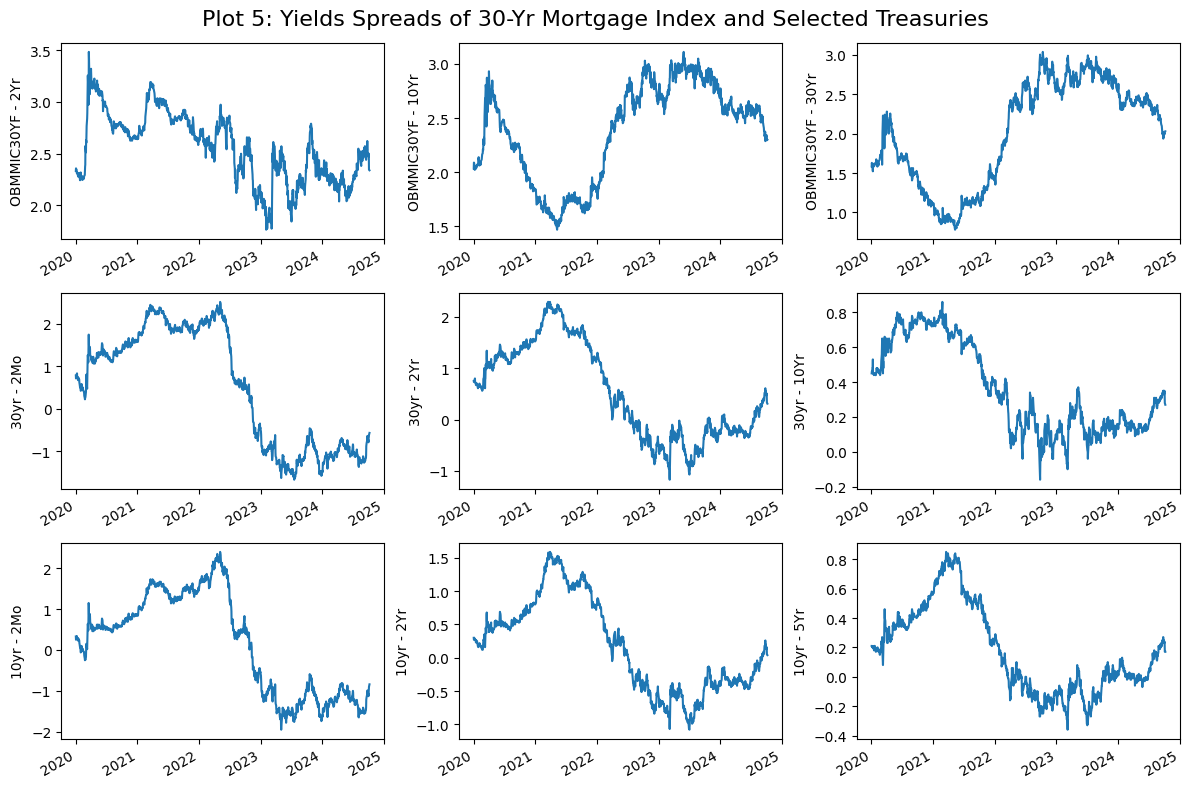

In [21]:
# visualizations of yield spreads

mortg_index_viz_df = create_features(df[['OBMMIC30YF']]).copy(deep=True) 
yr30_viz_df = create_features(df[['30 Yr']]).copy(deep=True) 
yr2_viz_df = create_features(df[['2 Yr']]).copy(deep=True) 
mo2_viz_df = create_features(df[['2 Mo']]).copy(deep=True) 

# build box plots
fig, axes = plt.subplots(ncols=3, nrows=3, figsize=(12,8))
axes_flat = axes.flatten()
ax_11, ax_12, ax_13, ax_21, ax_22, ax_23, ax_31, ax_32, ax_33 = axes_flat

#
(df['OBMMIC30YF'] - df['2 Yr']).plot(ax=ax_11, ylabel='OBMMIC30YF - 2Yr')
(df['OBMMIC30YF'] - df['10 Yr']).plot(ax=ax_12, ylabel='OBMMIC30YF - 10Yr')
(df['OBMMIC30YF'] - df['30 Yr']).plot(ax=ax_13, ylabel='OBMMIC30YF - 30Yr')


# 
(df['30 Yr'] - df['2 Mo']).plot(ax=ax_21, ylabel='30yr - 2Mo')
(df['30 Yr'] - df['2 Yr']).plot(ax=ax_22, ylabel='30yr - 2Yr')
(df['30 Yr'] - df['10 Yr']).plot(ax=ax_23, ylabel='30yr - 10Yr')

# 
(df['10 Yr'] - df['2 Mo']).plot(ax=ax_31, ylabel='10yr - 2Mo')
(df['10 Yr'] - df['2 Yr']).plot(ax=ax_32, ylabel='10yr - 2Yr')
(df['10 Yr'] - df['5 Yr']).plot(ax=ax_33, ylabel='10yr - 5Yr')


fig.suptitle("Plot 5: Yields Spreads of 30-Yr Mortgage Index and Selected Treasuries", fontsize=16)
plt.tight_layout()
plt.show()


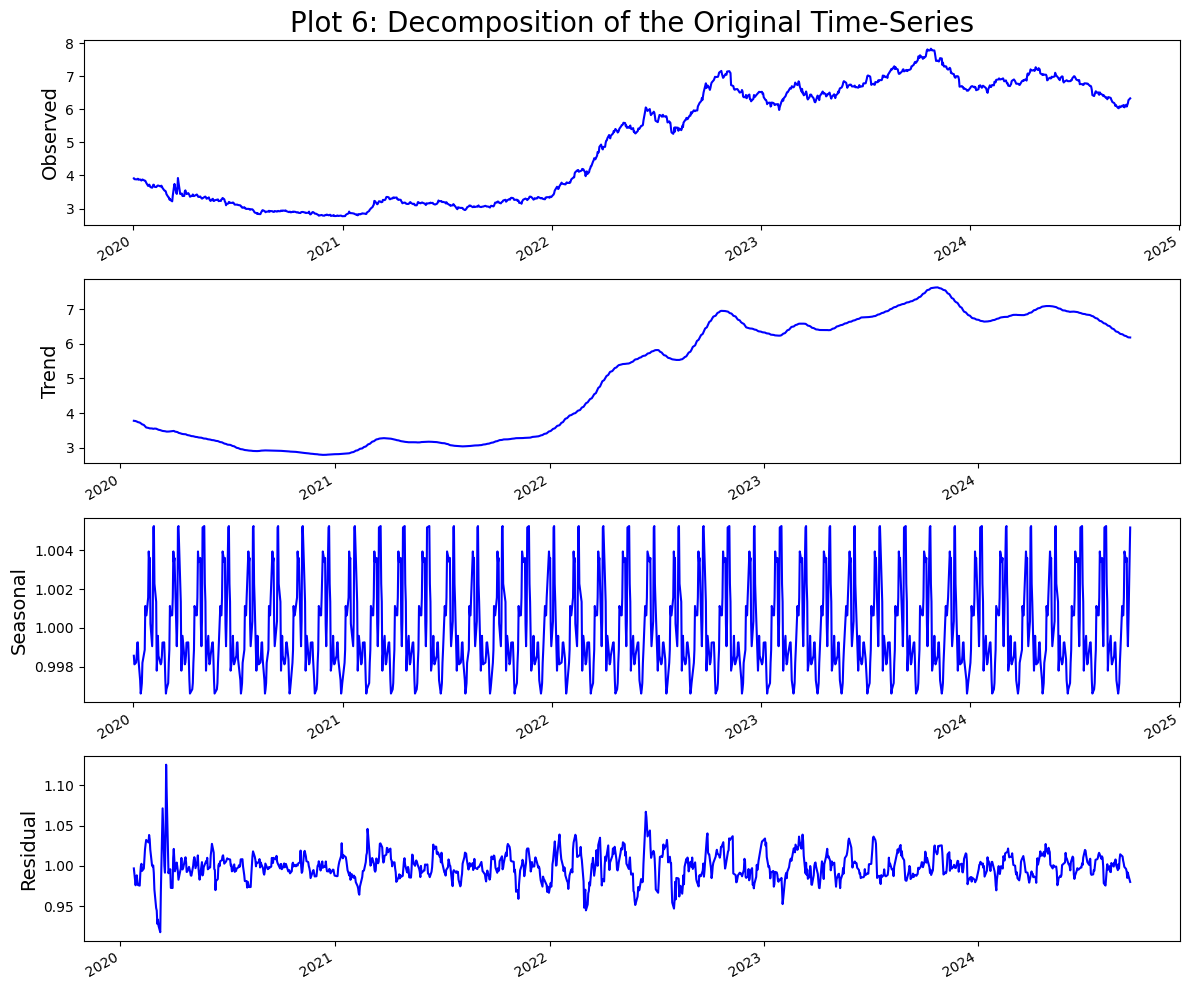

In [22]:
# visualize the seasonal & trend components of the original time-series
result = seasonal_decompose(df['OBMMIC30YF'], model='multiplicative', period=30)

fig, (ax1, ax2, ax3, ax4) = plt.subplots(nrows=4, ncols=1, figsize=(12,10))

# Observed
result.observed.plot(ax=ax1, color='blue')
ax1.set_title('Plot 6: Decomposition of the Original Time-Series', fontsize=20)
ax1.set_ylabel('Observed', fontsize=14)

# Trend
result.trend.plot(ax=ax2, color='blue')
ax2.set_ylabel('Trend', fontsize=14)

# Seasonal
result.seasonal.plot(ax=ax3, color='blue')
ax3.set_ylabel('Seasonal', fontsize=14)

# Residual
result.resid.plot(ax=ax4, color='blue')
ax4.set_ylabel('Residual', fontsize=14)


plt.tight_layout()
plt.show()

From the seasonal decomposition Plot 6 above, it can be observed that there is no considerable seasonality component for the 30-Yr Fixed Mortgage Index 

*

<span style="font-size: 20px">(3a) Method 0: Naive Model</span>

Random Walk ~ ARIMA(0,1,0)

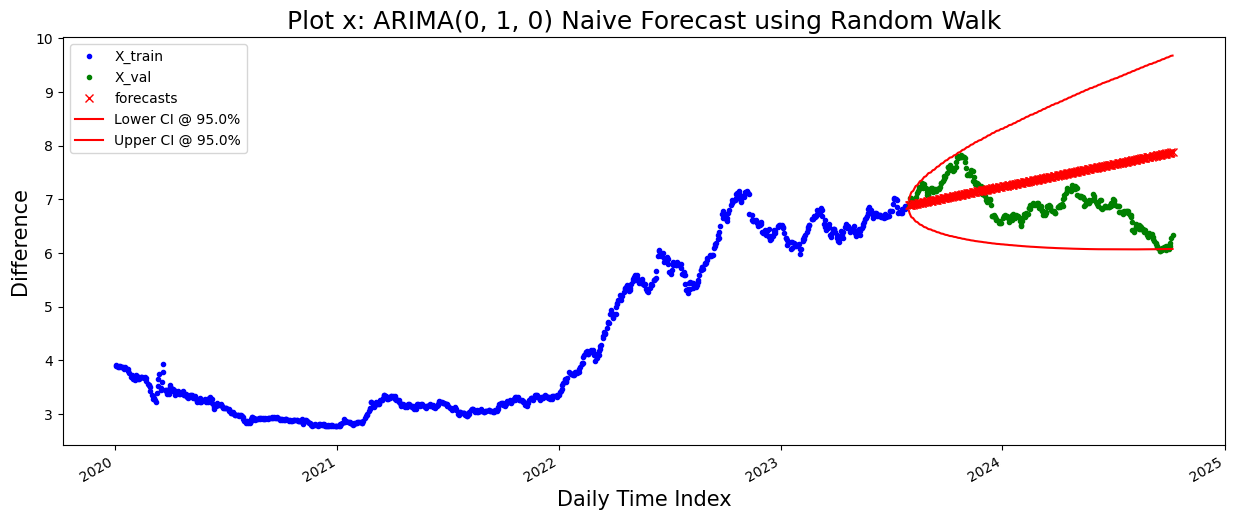

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  895
Model:               SARIMAX(0, 1, 0)   Log Likelihood                1355.903
Date:                Tue, 01 Jul 2025   AIC                          -2707.805
Time:                        13:55:22   BIC                          -2698.214
Sample:                             0   HQIC                         -2704.140
                                - 895                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0033      0.002      1.861      0.063      -0.000       0.007
sigma2         0.0028   6.02e-05     46.863      0.000       0.003       0.003
===================================================================================
Ljung-Box (L1) (Q):                  35.07   Jarque-Bera (JB):              2345.09
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               2.19   Skew:                            -0.29
Prob(H) (two-sided):                  0.00   Kurtosis:                        10.91
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

Correlation Matrix of Parameters


,intercept,sigma2
intercept,1.000000,0.093486
sigma2,0.093486,1.000000


parameter/SE ratio


intercept     1.861226
sigma2       46.862857
dtype: float64

In [77]:
# split original time series to training and validation data
perc_train = 0.75 # define percentage of time series to be the training set and the rest will be the validating set
X_train = df[['OBMMIC30YF']].iloc[ : int(len(df)*perc_train ) ] 
X_val = df[['OBMMIC30YF']].iloc[ int(len(df)*perc_train ) :  ]

order = (0,1,0) # random walk

# instantiate and fit the ARIMA model
arima_model = ARIMA(order=order)

# forecasting
h = len(X_val) # forecast horizon
alpha = 0.05 # significant level for confidence intervals
# extract forecasts and confidence intervals
arima_fc_summary_df = arima_model.fit(X_train['OBMMIC30YF']).arima_res_.get_forecast(h).summary_frame(alpha=alpha)
arima_fc_summary_df.index = X_val.index

# plotting
plt.figure(figsize=(15,6))
# plot training & validation data
X_train['OBMMIC30YF'].plot(style='.', color='blue', label='X_train')
X_val['OBMMIC30YF'].plot(style='.', color='green', label='X_val')
# plot forecasts and confidence intervals
arima_fc_summary_df['mean'].plot(style='x', color='red', label='forecasts')
arima_fc_summary_df['mean_ci_lower'].plot(kind='line', color='red', label=f'Lower CI @ {(1-alpha)*100}%')
arima_fc_summary_df['mean_ci_upper'].plot(kind='line', color='red', label=f'Upper CI @ {(1-alpha)*100}%')

plt.title(f'Plot x: ARIMA{order} Naive Forecast using Random Walk',fontsize=18)
plt.xlabel('Daily Time Index', fontsize=15) 
plt.ylabel('Difference', fontsize=15) 
plt.legend()
plt.show()

# showing summary of outputs from the model
display(arima_model.summary())

# print correlation matrix of parameters
cov_params_matrix = arima_model.arima_res_.cov_params()
std_devs = np.sqrt( np.diag(cov_params_matrix) )
corr_params_matrix = cov_params_matrix / np.outer(std_devs, std_devs)
print('Correlation Matrix of Parameters')
display(corr_params_matrix)

# print parameters/standard error (check if > 2 to be significant)
print('parameter/SE ratio')
display( np.abs(arima_model.arima_res_.params / arima_model.arima_res_.bse) )


Define Accuracy Metrics function for evaluating models

In [80]:
# define accuracy metrics
def accuracy_metrics(actual_values, forecasted_values):
    # pre-process input df: only grab the rows in actual values that are aligned with the indices of the forecasted values
    forecasted_values = forecasted_values.dropna().copy(deep=True)
    actual_values = actual_values.iloc[-len(forecasted_values):].copy(deep=True) 
    # convert to arrays
    forecasted_values_arr = np.array(forecasted_values)
    actual_values_arr = np.array(actual_values)



    # compute the metrics and store in dict
    metrics_dict = {
        'MAE' : np.mean(np.abs(actual_values_arr - forecasted_values_arr)),
        'RMSE': np.sqrt( np.mean( (actual_values_arr - forecasted_values_arr)**2 ) ),
        'MAPE': np.mean( np.abs( (actual_values_arr - forecasted_values_arr)/actual_values_arr ) )*100,
        'SMAPE': 100 * np.mean(2 * np.abs(actual_values_arr - forecasted_values_arr) / ( np.abs(actual_values_arr) + np.abs(forecasted_values_arr) )  ),
        'MdAPE': np.median( np.abs( (actual_values_arr - forecasted_values_arr)/actual_values_arr ) )*100,
        'GMRAE': np.exp( np.mean( np.log( np.abs( (actual_values_arr - forecasted_values_arr)/actual_values_arr ) ) ) ) 

    }

    # returns a df
    return pd.DataFrame(index=metrics_dict.keys(), data=metrics_dict.values(), columns=['accuracy metrics'])


In [88]:
# ARIMA(0,1,0) accuracy metrics
arima_naive_rw = round(accuracy_metrics(df['OBMMIC30YF'].loc[X_val.index], arima_fc_summary_df['mean'])*100, 3)
arima_naive_rw.columns = ['ARIMA RW Naive Accuracy %']
arima_naive_rw

,ARIMA RW Naive Accuracy %
MAE,65.511
RMSE,78.693
MAPE,979.916
SMAPE,919.996
MdAPE,854.138
GMRAE,7.335


Naive Model: y_n(h) = y_n for all h

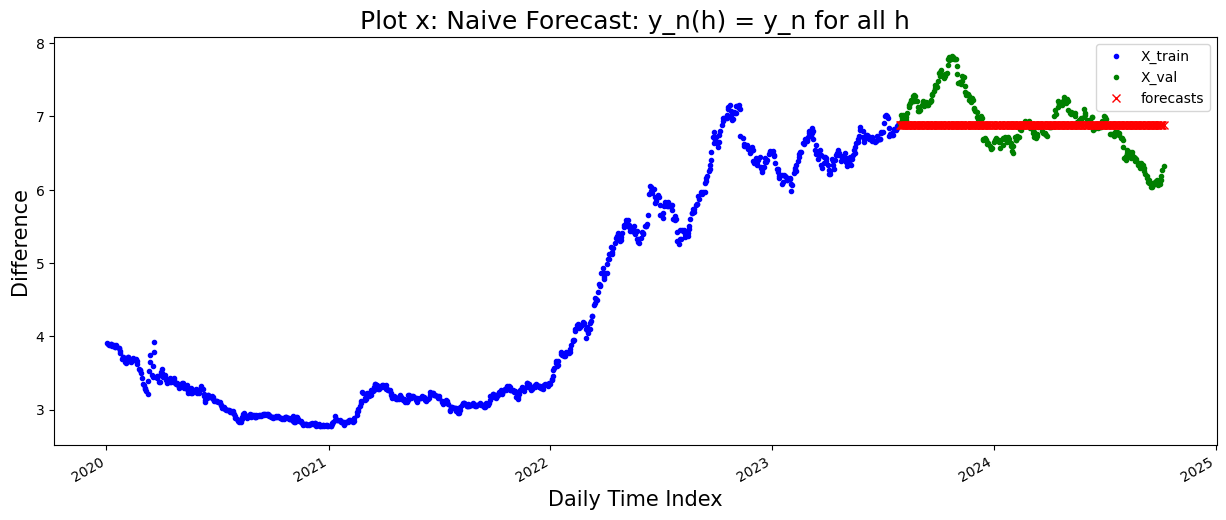

In [101]:
# define naive model
naive_forecast_df = pd.DataFrame(data=[X_train['OBMMIC30YF'].iloc[-1] for x in range(0, len(X_val.index))], columns=['naive'], index=X_val.index )

# plotting
plt.figure(figsize=(15,6))
# plot training & validation data
X_train['OBMMIC30YF'].plot(style='.', color='blue', label='X_train')
X_val['OBMMIC30YF'].plot(style='.', color='green', label='X_val')
# plot forecasts and confidence intervals
naive_forecast_df['naive'].plot(style='x', color='red', label='forecasts')

plt.title(f'Plot x: Naive Forecast: y_n(h) = y_n for all h',fontsize=18)
plt.xlabel('Daily Time Index', fontsize=15) 
plt.ylabel('Difference', fontsize=15) 
plt.legend()
plt.show()

In [100]:
# ARIMA(0,1,0) accuracy metrics
arima_naive = round(accuracy_metrics(df['OBMMIC30YF'].loc[X_val.index], naive_forecast_df['naive'])*100, 3)
arima_naive.columns = ['ARIMA Naive Accuracy %']
arima_naive

,ARIMA Naive Accuracy %
MAE,30.185
RMSE,39.340
MAPE,438.363
SMAPE,437.730
MdAPE,319.388
GMRAE,0.000


<span style="font-size: 20px">(3a) Method 1: Deploy Box-Jenkins approach to build a univariate time-series ARIMA model for the 30-Yr Fixed Rate Mortgage Index</span>

Transformations and Differencing

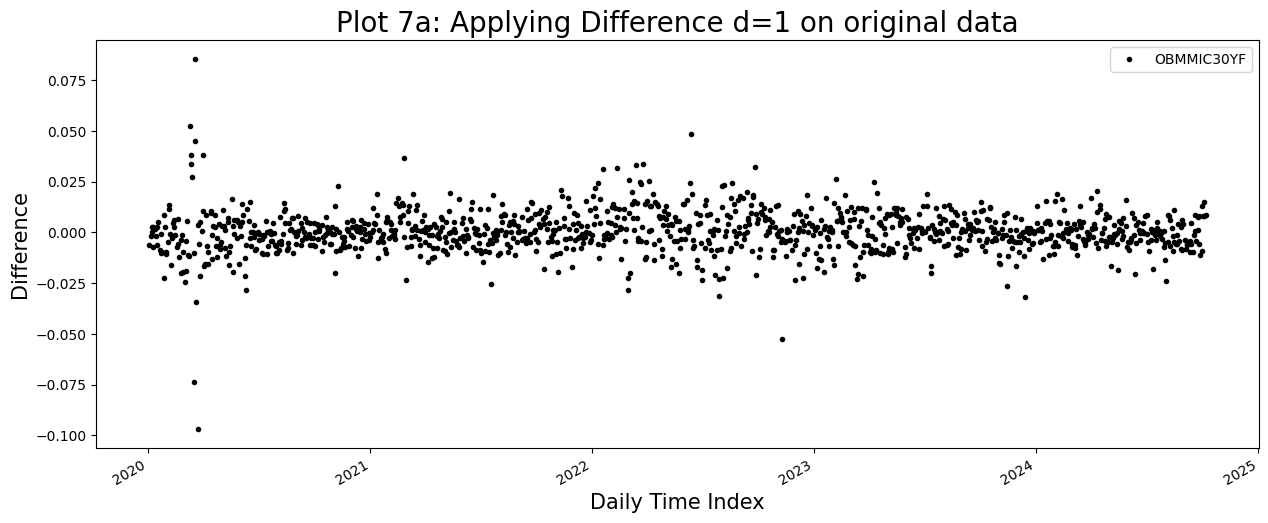

In [109]:
# apply log transformation and differencing on the mortgage index time-series
d = 1
transformed_df = np.log(df[['OBMMIC30YF']]).copy(deep=True) # apply log transformation


diff_df = df[['OBMMIC30YF']].diff(d) 
diff_df = transformed_df.diff(d) # apply simple differencing
diff_df = diff_df.dropna()

# plotting differenced data
fig = plt.figure(figsize=(15,6))
diff_df["OBMMIC30YF"].plot(style='.', color='black')

plt.title(f'Plot 7a: Applying Difference d={d} on original data', fontsize=20)
plt.ylabel('Difference', fontsize=15)
plt.xlabel('Daily Time Index', fontsize=15)

plt.legend()
plt.show()



When d=1 differencing is applied on the mortgage index, it can be observed that the difference are small because, like interest rates, 30-Yr Fixed Mortgage Index move in small increments in the magnitudes of basis points. 

*

Check for outliers

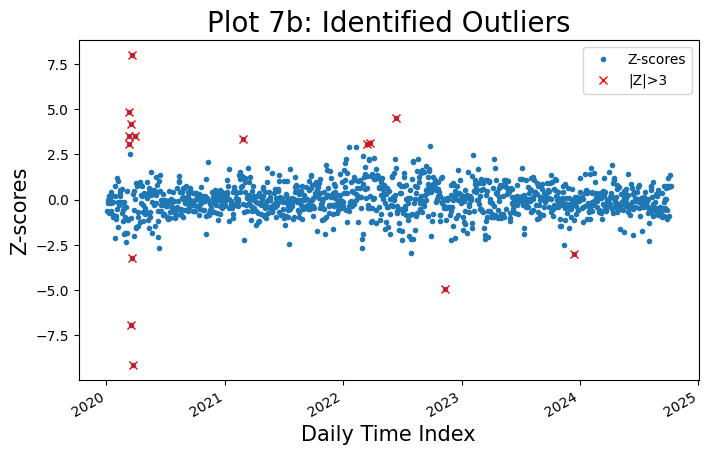

In [113]:
# use z-scores to identify outlers (|Z|>3)
z_score_df = (diff_df - diff_df.mean()) / diff_df.std()

fig = plt.figure(figsize=(8,5))
z_score_df['OBMMIC30YF'].plot(style='.', label='Z-scores') #.sort_values(by='OBMMIC30YF')
z_score_df[ np.abs(z_score_df['OBMMIC30YF']) > 3 ]['OBMMIC30YF'].plot(style='x', color='red', label='|Z|>3')

plt.ylabel('Z-scores', fontsize=15)
plt.xlabel('Daily Time Index', fontsize=15)
plt.title(f'Plot 7b: Identified Outliers', fontsize=20)

plt.legend()

Text(0.5, 1.0, 'Plot 7c: Identified Outliers on Original Domain ')

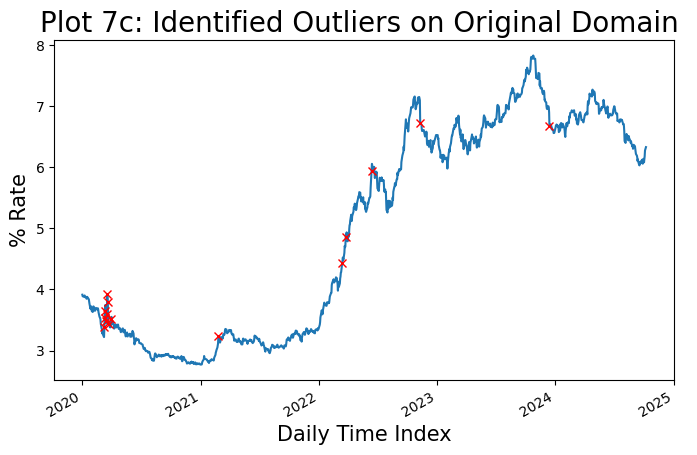

In [114]:
# show outliers on original mortgage index series
fig = plt.figure(figsize=(8,5))
z_score_outliers_df = z_score_df[ np.abs(z_score_df['OBMMIC30YF']) > 3 ][['OBMMIC30YF']]

df['OBMMIC30YF'].plot()
df['OBMMIC30YF'].loc[z_score_outliers_df.index].plot(style='x', color='red', label='Outliers')

plt.ylabel('% Rate', fontsize=15)
plt.xlabel('Daily Time Index', fontsize=15)
plt.title(f'Plot 7c: Identified Outliers on Original Domain ', fontsize=20)

Stationary Tests

In [115]:
# Test 1 for Stationarity
# Augmented Dickey Fuller (ADF) test

# Null Hypothesis: The series has a unit root. (not stationary - roots of the B-operator is within the unit circle)
# Alternate Hypothesis: The series has no unit root. (stationary - roots of the B-operator is outside the unit circle)
# If the null hypothesis in failed to be rejected, this test may provide evidence that the series is non-stationary.

from statsmodels.tsa.stattools import adfuller

def adf_test(timeseries):
    print('Results of ADF Test: ')
    dftest = adfuller(timeseries, autolag='AIC')
    dfoutput = pd.Series(
        dftest[0:4], # returns a tuple containing numerical results from the test
        # labels the numerical results from adfuller
        index = [
            'Test Statistic',
            'p-value',
            '#Lags Used',
            'Number of Observations Used'
        ]
    )
    # extracts the dictionary of resulting critical values from adfuller
    for key, value in dftest[4].items():
        dfoutput['Critical Value (%s)' % key] = value

    print(dfoutput) # returns the output df

    # Reject or Do Not Reject Null Hypothesis?
    crit_values = [0.01, 0.05, 0.10]
    p_value = dftest[1]

    for alpha in crit_values:
        if p_value < alpha:
            print(f'@ Critical Value ({int(alpha*100)}%) ---> Reject Null Hypothesis = Time-series is Stationary')
        else:
            print(f'@ Critical Value ({int(alpha*100)}%) ---> Failed to Reject Null Hypothesis = Time-series is Not Stationary')


adf_test(diff_df['OBMMIC30YF'])


Results of ADF Test: 
Test Statistic                -1.170849e+01
p-value                        1.508676e-21
#Lags Used                     6.000000e+00
Number of Observations Used    1.186000e+03
Critical Value (1%)           -3.435876e+00
Critical Value (5%)           -2.863980e+00
Critical Value (10%)          -2.568069e+00
dtype: float64
@ Critical Value (1%) ---> Reject Null Hypothesis = Time-series is Stationary
@ Critical Value (5%) ---> Reject Null Hypothesis = Time-series is Stationary
@ Critical Value (10%) ---> Reject Null Hypothesis = Time-series is Stationary


In [116]:
# Test 2 for stationarity
# Kwiatkowski-Phillips-Schmidt-Shin (“KPSS”) test

# Null Hypothesis: The process is trend stationary. (i.e. trend is constant)
# Alternate Hypothesis: The series has a unit root (series is not stationary).

from statsmodels.tsa.stattools import kpss

def kpss_test(timeseries):
    print('Results of KPSS Test:')
    kpsstest = kpss(timeseries, regression='c', nlags='auto')
    kpss_output = pd.Series(
        kpsstest[0:3], 
        index=['Test Statistic',
                    'p-value',
                    'Lags Used']
    )

    for key, value in kpsstest[3].items():
        kpss_output['Critical Value (%s)' % key] = value

    print(kpss_output)

    # Reject or Failed to Reject Null Hypothesis
    crit_values = [0.10, 0.05, 0.025, 0.01]
    p_value = kpsstest[1]
    for alpha in crit_values:
        if p_value < alpha:
            print(f'@ Critical Value ({int(alpha*100)}%) ---> Reject Null Hypothesis = Time-series is Not Stationary')
        else:
            print(f'@ Critical Value ({int(alpha*100)}%) ---> Failed to Reject Null Hypothesis = Time-series is [Trend] Stationary')


kpss_test(diff_df['OBMMIC30YF'])


Results of KPSS Test:
Test Statistic           0.445634
p-value                  0.057485
Lags Used                4.000000
Critical Value (10%)     0.347000
Critical Value (5%)      0.463000
Critical Value (2.5%)    0.574000
Critical Value (1%)      0.739000
dtype: float64
@ Critical Value (10%) ---> Reject Null Hypothesis = Time-series is Not Stationary
@ Critical Value (5%) ---> Failed to Reject Null Hypothesis = Time-series is [Trend] Stationary
@ Critical Value (2%) ---> Failed to Reject Null Hypothesis = Time-series is [Trend] Stationary
@ Critical Value (1%) ---> Failed to Reject Null Hypothesis = Time-series is [Trend] Stationary


ACF and PACF plots for estimating initial ARIMA parameters

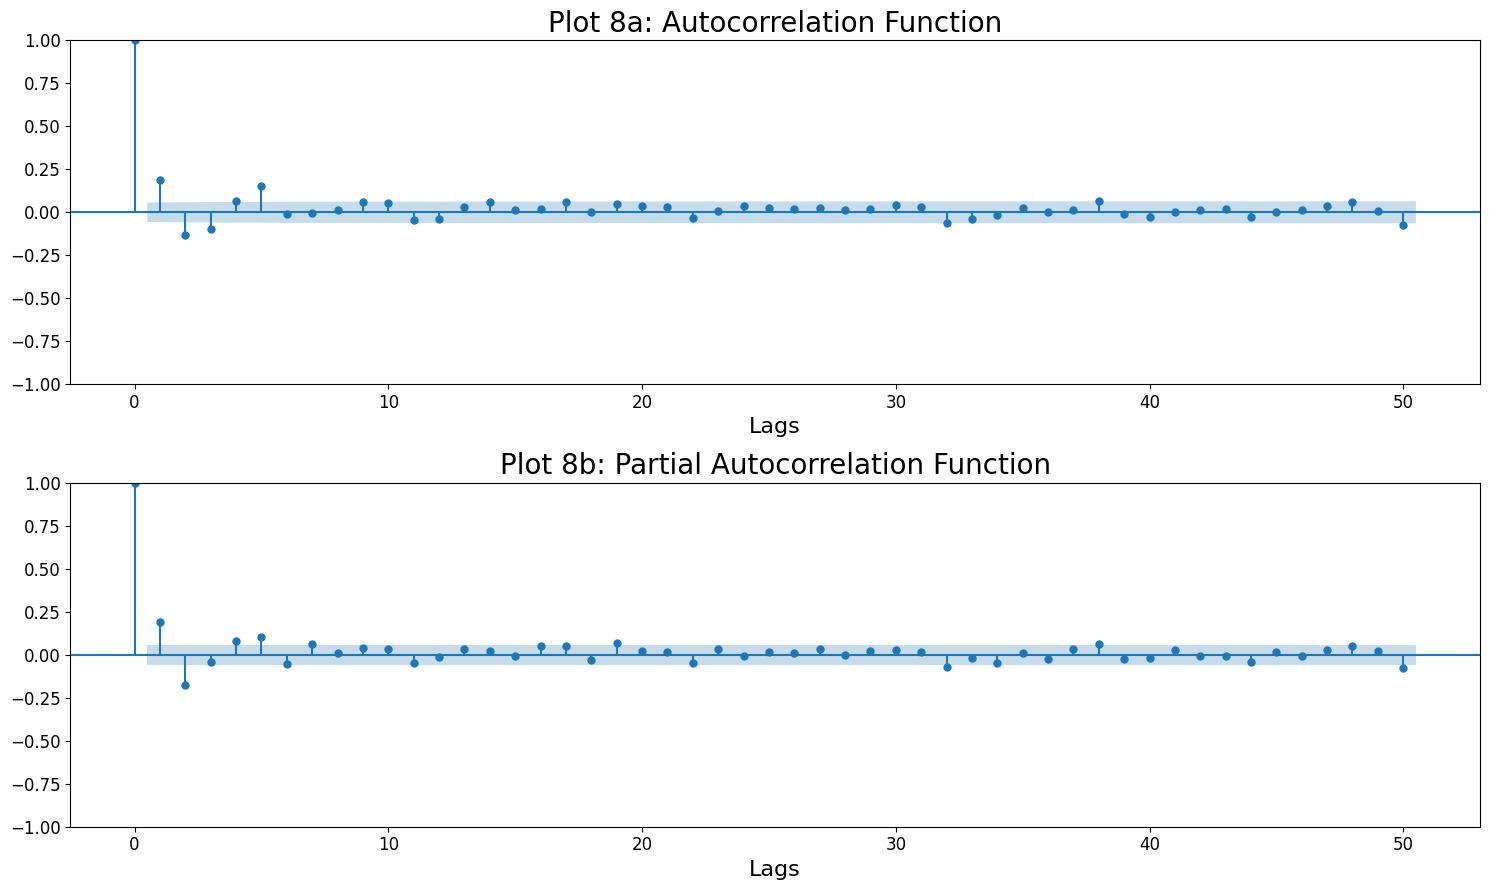

In [117]:
# plot ACF and PACF
fig, axes = plt.subplots(ncols=1, nrows=2, figsize=(15,9))
axes_flat = axes.flatten()
ax_1, ax_2 = axes_flat

# ACF
plot_acf(diff_df['OBMMIC30YF'], lags=50, alpha=0.05, ax=ax_1)
ax_1.set_title('Plot 8a: Autocorrelation Function', fontsize=20)
ax_1.set_xlabel('Lags', fontsize=16)
ax_1.tick_params(axis='both', labelsize=12)

# PACF
plot_pacf(diff_df['OBMMIC30YF'], lags=50, alpha=0.05, ax=ax_2)
ax_2.set_title('Plot 8b: Partial Autocorrelation Function', fontsize=20)
ax_2.set_xlabel('Lags', fontsize=16)
ax_2.tick_params(axis='both', labelsize=12)

plt.tight_layout()
plt.show()


Based from the above ACF & PACF plots, the following are plausible starting parameters for the ARIMA(p,d,q) model:    ARIMA(2,1,0), ARIMA(0,1,2)

*

Deploy Grid Search around the starting parameters to look for the optimal parameters based on lowest AIC scores

In [118]:
# Grid Search to find the best parameters based on the lowest AIC

# based from the ACF and PACF plots, choose ranges of parameter values for the ARIMA model 
p = range(0,2+1) # p=0 to 2
d = range(1,2) # d=1
q = range(0,2+1) # q=0 to 2

# split train and test set 
perc_train = 0.75 # percent of dataset that will be assinged as training/fitting set
X_train = diff_df.iloc[:int( len(diff_df)*perc_train )]
X_val = diff_df.iloc[int( len(diff_df)*perc_train ):]

# all possible permutations of parameter values are fed into the SARIMA model and obtain corresponding AIC value

aic_dict = dict() # tracks AIC values
for w in [x for x in product(p,d,q)]:
    # extract non-seasonal and seasonal orders from the current iteration
    order = w[:3]

    # train SARIMA model and extract AIC
    model = SARIMAX(X_train['OBMMIC30YF'], order=order).fit()

    # checks for parameter value / standard error ratio > 2 to be significant
    sum = np.sum( np.abs(model.params / model.bse) > 2 ) # if one of the parameters satisfies > 2, should return True=1
    # only include models that satisfy the above condition
    if sum != 0:
        aic_dict[model.aic] = (order) # store the aic value and corresponding order and seasonal order combination


# extract the lowest AIC values 
aic_list = [i for i in aic_dict.keys()]
aic_arr = np.array(aic_list)
aic_lowest = np.sort(aic_arr)[:15] # lowest AIC values

# outputs the five best parameters to further check:
for aic in aic_lowest:
    print(f'AIC = {aic} : {aic_dict[aic]}')

warnings.filterwarnings('ignore')


AIC = -5496.2736667755 : (2, 1, 1)
AIC = -5479.199187211111 : (2, 1, 2)
AIC = -5472.949208530225 : (1, 1, 2)
AIC = -5472.284739136218 : (0, 1, 2)
AIC = -5457.768651887482 : (1, 1, 1)
AIC = -5428.862718275833 : (0, 1, 1)
AIC = -5188.762712262128 : (2, 1, 0)
AIC = -5078.11200693697 : (1, 1, 0)
AIC = -5005.553550901832 : (0, 1, 0)


Build the ARIMA model with the obtained optimal parameters

Split the transformed & differenced time-series set from inception to 2023-07-28 as the training/fitting set while all dates beyond this date is the validation set

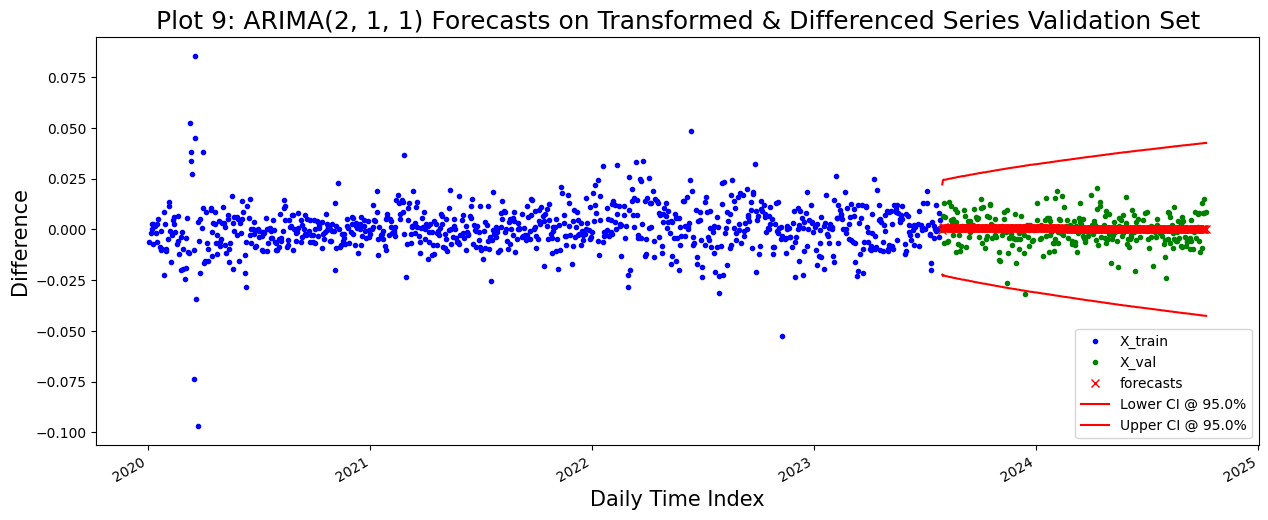

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  894
Model:               SARIMAX(2, 1, 1)   Log Likelihood                2737.644
Date:                Wed, 02 Jul 2025   AIC                          -5465.289
Time:                        23:00:56   BIC                          -5441.316
Sample:                             0   HQIC                         -5456.128
                                - 894                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept  -2.623e-06   3.69e-05     -0.071      0.943    -7.5e-05    6.98e-05
ar.L1          0.2566      0.021     12.172      0.000       0.215       0.298
ar.L2         -0.2391      0.019    -12.766      0.000      -0.276      -0.202
ma.L1         -0.9088      0.016    -57.381      0.000      -0.940      -0.878
sigma2         0.0001   3.37e-06     38.126      0.000       0.000       0.000
===================================================================================
Ljung-Box (L1) (Q):                   9.50   Jarque-Bera (JB):              2247.78
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               0.78   Skew:                            -0.32
Prob(H) (two-sided):                  0.03   Kurtosis:                        10.75
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

Correlation Matrix of Parameters


,intercept,ar.L1,ar.L2,ma.L1,sigma2
intercept,1.000000,0.051573,-0.019604,-0.215596,-0.053549
ar.L1,0.051573,1.000000,0.323221,-0.662631,-0.298023
ar.L2,-0.019604,0.323221,1.000000,-0.519524,0.173725
ma.L1,-0.215596,-0.662631,-0.519524,1.000000,0.356061
sigma2,-0.053549,-0.298023,0.173725,0.356061,1.000000


parameter/SE ratio


intercept     0.071002
ar.L1        12.171598
ar.L2        12.766158
ma.L1        57.380866
sigma2       38.125671
dtype: float64

In [120]:
# split original time series to training and validation data
perc_train = 0.75 # define percentage of time series to be the training set and the rest will be the validating set
X_train = diff_df.iloc[ : int(len(diff_df)*perc_train ) ] 
X_val = diff_df.iloc[ int(len(diff_df)*perc_train ) :  ]


# define the parameters of the ARIMA model as found above
order = (2,1,1) # non-seasonal

# instantiate and fit the ARIMA model
arima_model = ARIMA(order=order)

# forecasting
h = len(X_val) # forecast horizon
alpha = 0.05 # significant level for confidence intervals
# extract forecasts and confidence intervals
arima_fc_summary_df = arima_model.fit(X_train['OBMMIC30YF']).arima_res_.get_forecast(h).summary_frame(alpha=alpha)
arima_fc_summary_df.index = X_val.index

# plotting
plt.figure(figsize=(15,6))
# plot training & validation data
X_train['OBMMIC30YF'].plot(style='.', color='blue', label='X_train')
X_val['OBMMIC30YF'].plot(style='.', color='green', label='X_val')
# plot forecasts and confidence intervals
arima_fc_summary_df['mean'].plot(style='x', color='red', label='forecasts')
arima_fc_summary_df['mean_ci_lower'].plot(kind='line', color='red', label=f'Lower CI @ {(1-alpha)*100}%')
arima_fc_summary_df['mean_ci_upper'].plot(kind='line', color='red', label=f'Upper CI @ {(1-alpha)*100}%')

plt.title(f'Plot 9: ARIMA{order} Forecasts on Transformed & Differenced Series Validation Set',fontsize=18)
plt.xlabel('Daily Time Index', fontsize=15) 
plt.ylabel('Difference', fontsize=15) 
plt.legend()
plt.show()

# showing summary of outputs from the model
display(arima_model.summary())

# print correlation matrix of parameters
cov_params_matrix = arima_model.arima_res_.cov_params()
std_devs = np.sqrt( np.diag(cov_params_matrix) )
corr_params_matrix = cov_params_matrix / np.outer(std_devs, std_devs)
print('Correlation Matrix of Parameters')
display(corr_params_matrix)

# print parameters/standard error (check if > 2 to be significant)
print('parameter/SE ratio')
display( np.abs(arima_model.arima_res_.params / arima_model.arima_res_.bse) )


Residual Analysis

Note: I think what should have been done was to use the model to do in-sample forecast and compare with training set - this must be done in original domain

In [131]:
# null hypothesis: errors/residuals follow white noise process (i.e. the errors are random or uncorrelated)

# obtain Ljung-Box test statistic and p-value
ljung_box_arr = arima_model.arima_res_.test_serial_correlation(method='ljungbox')

# extract statistic and p-value
ljung_box_extract = dict()
ljung_box_extract['Q-Statistic'] = ljung_box_arr.flatten()[0] # Q-statistic
ljung_box_extract['p-value'] = ljung_box_arr.flatten()[1]

# if p-value > 0.05, then fail to reject null hypothesis: errors/residuals follow white noise process (i.e. the errors are random or uncorrelated)
if ljung_box_extract['p-value'] > 0.05:
    ljung_box_extract['result'] = 'Errors are random'
else:
    ljung_box_extract['result'] = 'Errors are not random'


# obtain Box-Pierce test statistic and p-value
box_pierce_arr = arima_model.arima_res_.test_serial_correlation(method='boxpierce')

# extract statistic and p-value
box_pierce_extract = dict()
box_pierce_extract['Q-Statistic'] = box_pierce_arr.flatten()[0] # Q-statistic
box_pierce_extract['p-value'] = box_pierce_arr.flatten()[1]

# if p-value > 0.05, then fail to reject null hypothesis: errors/residuals follow white noise process (i.e. errors/residuals follow white noise process (i.e. the errors are random or uncorrelated)
if box_pierce_extract['p-value'] > 0.05:
    box_pierce_extract['result'] = 'Errors are random'
else:
    box_pierce_extract['result'] = 'Errors are not random'


lj_df = pd.DataFrame(data=ljung_box_extract.values(), index=ljung_box_extract.keys(), columns=['Ljung Box'])
bp_df = pd.DataFrame(data=box_pierce_extract.values(), index=box_pierce_extract.keys(), columns=['Box Pierce'])

residual_analysis_df = pd.concat([lj_df,bp_df], axis=1)
residual_analysis_df

,Ljung Box,Box Pierce
Q-Statistic,9.498945,9.467105
p-value,9.557592,9.52549
result,Errors are random,Errors are random


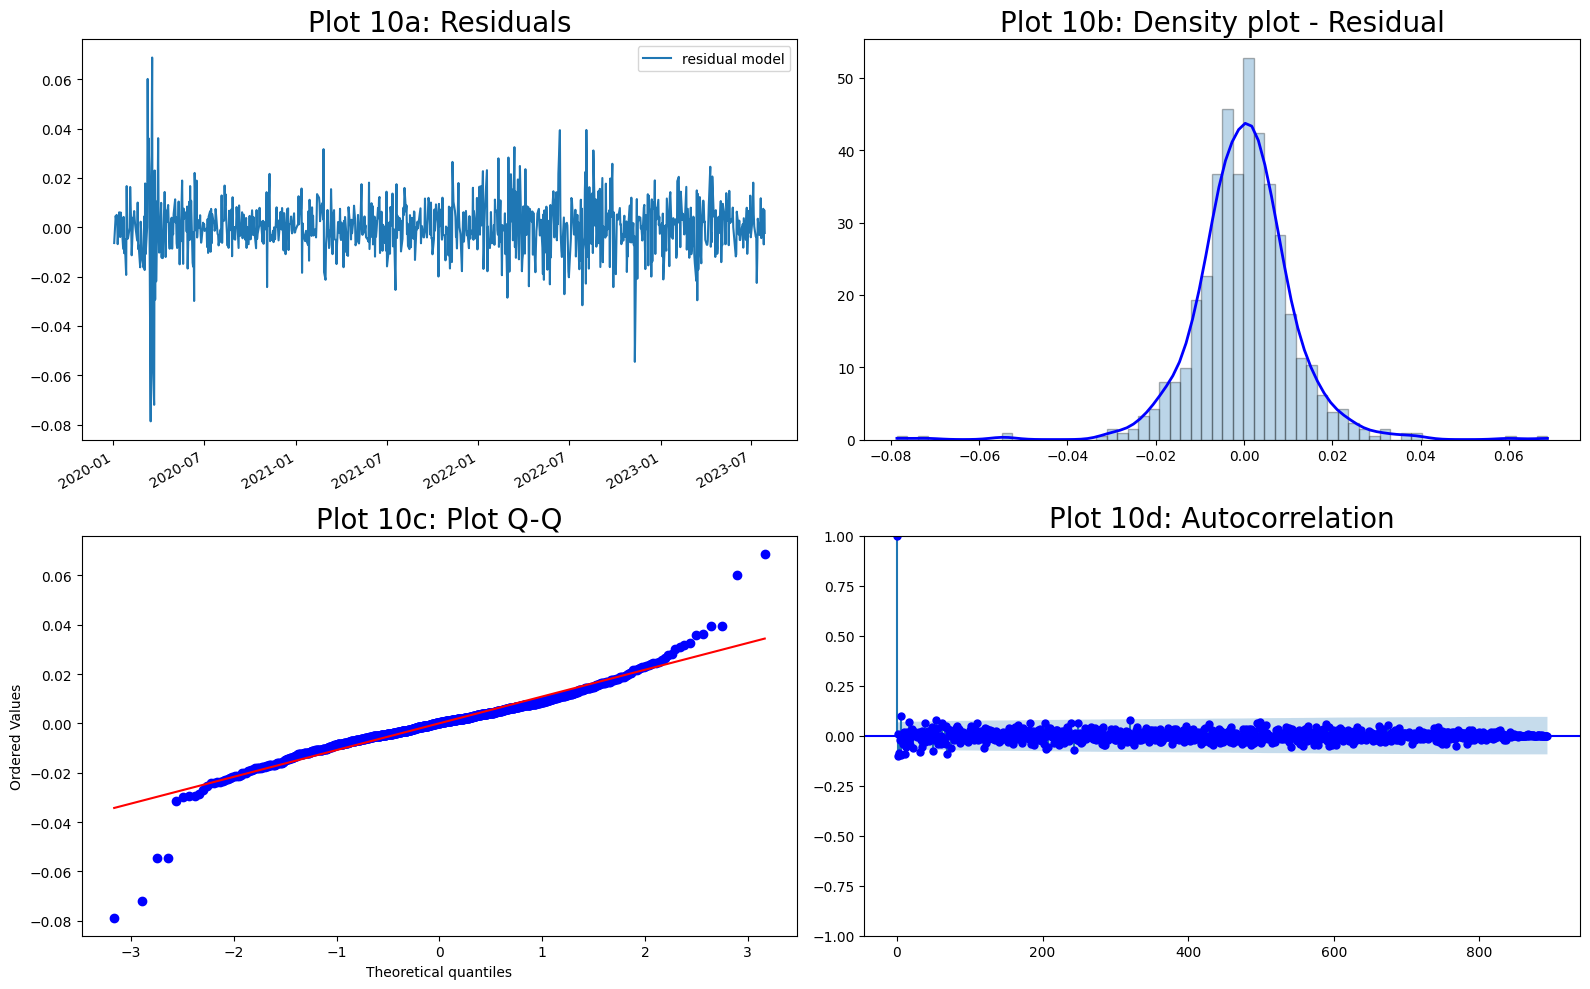

In [132]:
# extract residuals from the model
residual = pd.DataFrame(data=arima_model.resid(), columns=['residual model'])

fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(16,10))

# Residual Plot
residual.plot(ax=axs[0,0])
axs[0,0].set_title('Plot 10a: Residuals', fontsize=20)

# Density
# plot the hist
axs[0,1].hist(
    residual, bins='auto', density=True, alpha=0.30, edgecolor='black')
# plot density curve
kde = stats.gaussian_kde(residual['residual model'])
x_range = np.linspace(min(residual['residual model']), max(residual['residual model']), 100)
axs[0,1].plot(x_range, kde(x_range), linewidth=2, color='blue')
axs[0,1].set_title("Plot 10b: Density plot - Residual", fontsize=20)

# Q-Q plot
stats.probplot(residual["residual model"], dist="norm", plot=axs[1,0])
axs[1,0].set_title('Plot 10c: Plot Q-Q', fontsize=20)

# ACF plot
plot_acf(residual,  lags=len(residual)-1, ax=axs[1,1],color="blue")
axs[1,1].set_title("Plot 10d: Autocorrelation", fontsize=20)

plt.tight_layout()
plt.show()
 

Confirmed by Ljung-Box and Box-Pierce tests and visualizations (see above plots) that in-sample errors/residuals from the model are random white noise (normal IID)

*

Transforming the forecasts of the ARIMA back to the original domain, effectively undoing the transformation and differencing

In [133]:
# extract fitted coefficients
param_dict = dict(arima_model.arima_res_.params)
theta1 = param_dict['ma.L1']
phi1 = param_dict['ar.L1']
phi2 = param_dict['ar.L2']

param_dict

{'intercept': -2.622517007467636e-06,
 'ar.L1': 0.2565951644320379,
 'ar.L2': -0.2390805274881326,
 'ma.L1': -0.9088355825333134,
 'sigma2': 0.00012856999498200744}

In [135]:
# define a list containing preliminary and forecasted values of transformed & differenced validation set
del_n_h = [x[0] for x in np.array(X_train.iloc[-3:].diff(1).dropna()) ] + list(arima_fc_summary_df['mean'])

# white noise residual generator  
np.random.seed(1)
residual_n_h = np.random.normal(residual.mean(), residual.std(), len(del_n_h))

In [136]:
# initiate the list of forecasted values in the original domain
X_n_h = [df['OBMMIC30YF'].loc[X_train.index[-1]]] 

# do recursive computations in transforming forecasts to the original domain
for h in range(1, len(X_val)):

    # analytical formula for ARIMA(2,1,1) to transform forecasts to original domain 
    X = np.log( np.exp( X_n_h[h-1] ) + phi1*del_n_h[h] + phi2*del_n_h[h-1] + theta1*residual_n_h[h-1] + residual_n_h[h])
    X_n_h.append(X)

del X_n_h[0:1] # deletes the first two values since they belong to the original dataset

forecast_df = pd.DataFrame(data=X_n_h, index=X_val.index[:-1])

In [138]:
# visualize forecasts and validation set
fig = go.Figure()

# Forecasts
fig.add_trace(go.Scatter(
    x=forecast_df.index, 
    y=forecast_df[forecast_df.columns[0]], 
    mode='lines', 
    name='Forecasts on Validation Set',
    line=dict(color='blue')
    
))

# Training/Fitting Set
fig.add_trace(go.Scatter(
    x=df.index, 
    y=df['OBMMIC30YF'], 
    mode='lines', 
    name='Training/Fitting Set',
    line=dict(color='green')
))

# Validation Set
fig.add_trace(go.Scatter(
    x=X_val.index, 
    y=df['OBMMIC30YF'].loc[X_val.index], 
    mode='lines', 
    name='Validation Set',
    line=dict(color='red')
))

# Validation Set
fig.add_trace(go.Scatter(
    x=X_val.index, 
    y=forecast_df[forecast_df.columns[0]] - df['OBMMIC30YF'].loc[X_val.index], 
    mode='lines', 
    name='Forecast - Validation Set Spread',
    line=dict(color='brown')
))

fig.update_layout(title={'text':'Plot 11: Univariate ARIMA(2,1,1) Forecasts on 30-Yr Fixed Mortgage Index',
                            'font': dict(size=20)}, 
                            xaxis_title='Daily Time Index', 
                            yaxis_title='% Rate')

fig.update_xaxes(title_font=dict(size=20))
fig.update_yaxes(title_font=dict(size=20))

fig.show()

On Plot 10, it can be observed that the forecasts of the ARIMA(2,1,1) in the original domain is simply the last value of the training/fitting set at 2023-07-28 date.  


To attempt to explain why this happen, recall that on Plot 8, the model also output a linear forecast on the transformed & differenced domain during validation. The differenced series of the Mortgage Index is so small in scale and close to zero that the ARIMA's forecasts hovered around there.

On another angle, the analytical formula of ARIMA(2,1,1) that was derived by hand (see companion ARIMA pdf) or the code implementation may be erroneous.

In the future, given more time, the potential sources of errors will be reviewed and Exponential Smoothing could be an alternative univariate model to be explored.

*

In [139]:
# ARIMA(2,1,1) accuracy metrics
arima_am = round(accuracy_metrics(df['OBMMIC30YF'].loc[X_val.index], forecast_df[forecast_df.columns[0]])*100, 3)
arima_am.columns = ['ARIMA Accuracy %']
arima_am 

,ARIMA Accuracy %
MAE,30.287
RMSE,39.407
MAPE,439.836
SMAPE,439.201
MdAPE,324.772
GMRAE,2.478


<span style="font-size: 20px">(3b) Method 2: ARIMAX model to incorporate treasury yields to forecast 30-Yr Fixed Rate Mortgage Index</span>

- incorporate Treasury Yields as exogenous variables in the model since some of these securities heavily influence mortgage rates 
- after a lot of trial and errors, 30Yr and 2Yr Treasuries are found to be the best exogenous variable pairs that result to the most accurate forecasts by ARIMAX
- if given more time, Grid Search on Treasury Yields to find optimal exogenous variables will add value in this application
- proceed with similar steps in model building as in the previous model

In [140]:
# Grid Search to find the best parameters based on the lowest AIC

# based from the ACF and PACF plots, choose ranges of parameter values for the ARIMA model 
p = range(0,2+1) # p=0 to 2
d = range(1,2) # d=1
q = range(0,2+1) # q=0 to 2

# split train and test set 
perc_train = 0.75 

# use original time-series dataset since stationa
X_train = df[['OBMMIC30YF']].iloc[ : int(len(df[['OBMMIC30YF']])*perc_train ) ] 
X_val = df[['OBMMIC30YF']].iloc[ int(len(df[['OBMMIC30YF']])*perc_train ) :  ]

# training and validation sets for exogenous/covariate variable
exog_train = df[['2 Yr', '30 Yr']].iloc[ : int(len(df)*perc_train ) ]
exog_val = df[['2 Yr', '30 Yr']].iloc[ int(len(df)*perc_train ) : ]


# using PCA result as exogenous variable
#exog_train = yield_curve_pca_df[['PCA']].iloc[ : int(len(df)*perc_train ) ]
#exog_val = yield_curve_pca_df[['PCA']].iloc[ int(len(df)*perc_train ) : ]

# all possible permutations of parameter values are fed into the SARIMAX model and obtain corresponding AIC value
aic_dict = dict() # tracks AIC values
for w in [x for x in product(p,d,q)]:
    # extract non-seasonal and seasonal orders from the current iteration
    order = w[:3]

    # train SARIMA model and extract AIC
    model = SARIMAX( X_train,
                    exog=exog_train,
                    order=order,
                    enforce_stationarity=True,
                    ).fit()

    # checks for parameter value / standard error ratio > 2 to be significant
    sum = np.sum( np.abs(model.params / model.bse) > 2 ) # if one of the parameters satisfies > 2, should return True=1
    # only include models that satisfy the above condition
    if sum != 0:
        aic_dict[model.aic] = (order) # store the aic value and corresponding order and seasonal order combination

# extract the lowest AIC values 
aic_list = [i for i in aic_dict.keys()]
aic_arr = np.array(aic_list)
aic_lowest = np.sort(aic_arr)[:15] # lowest AIC values

# outputs the five best parameters to further check:
for aic in aic_lowest:
    print(f'AIC = {aic} : {aic_dict[aic]}')

warnings.filterwarnings('ignore')

AIC = -3413.108849060357 : (2, 1, 2)
AIC = -3399.2621174923515 : (2, 1, 0)
AIC = -3398.8652538308506 : (2, 1, 1)
AIC = -3396.049235191186 : (0, 1, 2)
AIC = -3395.6629086429307 : (1, 1, 2)
AIC = -3389.523448453896 : (1, 1, 1)
AIC = -3389.07558227694 : (0, 1, 1)
AIC = -3388.218885050116 : (1, 1, 0)
AIC = -3387.727316843114 : (0, 1, 0)


Build the ARIMAX model

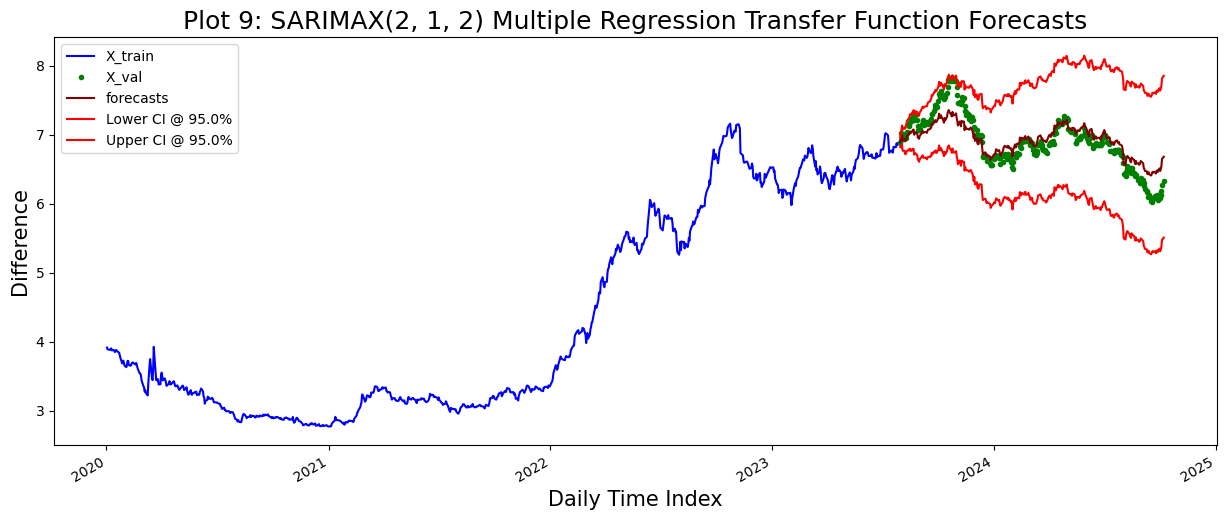

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:             OBMMIC30YF   No. Observations:                  895
Model:               SARIMAX(2, 1, 2)   Log Likelihood                1713.554
Date:                Sun, 06 Jul 2025   AIC                          -3413.109
Time:                        00:03:57   BIC                          -3379.539
Sample:                             0   HQIC                         -3400.281
                                - 895                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
2 Yr           0.3424      0.016     21.237      0.000       0.311       0.374
30 Yr          0.3490      0.016     21.883      0.000       0.318       0.380
ar.L1          0.2053      0.079      2.608      0.009       0.051       0.360
ar.L2         -0.7691      0.069    -11.161      0.000      -0.904      -0.634
ma.L1         -0.1377      0.091     -1.511      0.131      -0.316       0.041
ma.L2          0.6571      0.078      8.381      0.000       0.503       0.811
sigma2         0.0013   3.47e-05     36.445      0.000       0.001       0.001
===================================================================================
Ljung-Box (L1) (Q):                   0.05   Jarque-Bera (JB):              3412.69
Prob(Q):                              0.82   Prob(JB):                         0.00
Heteroskedasticity (H):               1.37   Skew:                             0.63
Prob(H) (two-sided):                  0.01   Kurtosis:                        12.49
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

Correlation Matrix of Parameters


,2 Yr,30 Yr,ar.L1,ar.L2,ma.L1,ma.L2,sigma2
2 Yr,1.000000,-0.657477,0.055584,0.088448,-0.033974,-0.116735,0.044436
30 Yr,-0.657477,1.000000,-0.058745,-0.051447,0.088229,0.100237,-0.171416
ar.L1,0.055584,-0.058745,1.000000,-0.192671,-0.976142,0.112381,-0.100251
ar.L2,0.088448,-0.051447,-0.192671,1.000000,0.216754,-0.984288,-0.029329
ma.L1,-0.033974,0.088229,-0.976142,0.216754,1.000000,-0.133040,-0.014856
ma.L2,-0.116735,0.100237,0.112381,-0.984288,-0.133040,1.000000,0.086734
sigma2,0.044436,-0.171416,-0.100251,-0.029329,-0.014856,0.086734,1.000000


parameter/SE ratio


2 Yr      21.237184
30 Yr     21.883273
ar.L1      2.608371
ar.L2     11.161045
ma.L1      1.511168
ma.L2      8.380548
sigma2    36.445203
dtype: float64

In [167]:
# use obtained optimal parameters
order = (2,1,2) # non-seasonal

# Create and fit the SARIMAX model
arimax_model = SARIMAX(
    X_train,
    exog=exog_train,
    order=order,
    enforce_stationarity=True
    ).fit()

# forecasting
y_pred = arimax_model.forecast(len(X_val), exog=exog_val )
y_pred = pd.DataFrame(data=np.array(y_pred), index=X_val.index)


# forecasting
h = len(exog_val) # forecast horizon
alpha = 0.05 # significant level for confidence intervals
# extract forecasts and confidence intervals
arimax_fc_summary_df = arimax_model.get_forecast(h, exog=exog_val).summary_frame(alpha=alpha)
arimax_fc_summary_df.index = X_val.index

# plotting
plt.figure(figsize=(15,6))
# plot training & validation data
X_train['OBMMIC30YF'].plot(kind='line', color='blue', label='X_train')
X_val['OBMMIC30YF'].plot(style='.', color='green', label='X_val')
# plot forecasts and confidence intervals
arimax_fc_summary_df['mean'].plot(kind='line', color='maroon', label='forecasts')
arimax_fc_summary_df['mean_ci_lower'].plot(kind='line', color='red', label=f'Lower CI @ {(1-alpha)*100}%')
arimax_fc_summary_df['mean_ci_upper'].plot(kind='line', color='red', label=f'Upper CI @ {(1-alpha)*100}%')

plt.title(f'Plot 9: SARIMAX{order} Multiple Regression Transfer Function Forecasts',fontsize=18)
plt.xlabel('Daily Time Index', fontsize=15) 
plt.ylabel('Difference', fontsize=15) 
plt.legend()
plt.show()


# showing summary of outputs from the model
display(arimax_model.summary())

# print correlation matrix of parameters
cov_params_matrix = arimax_model.cov_params()
std_devs = np.sqrt( np.diag(cov_params_matrix) )
corr_params_matrix = cov_params_matrix / np.outer(std_devs, std_devs)
print('Correlation Matrix of Parameters')
display(corr_params_matrix)

# print parameters/standard error (check if > 2 to be significant)
print('parameter/SE ratio')
display( np.abs(arimax_model.params / arimax_model.bse) )


Residual Analysis

In [168]:
# obtain Ljung-Box test statistic and p-value
# Null Hypothesis: residuals are white noise (residuals are uncorrelated)
# Alternative Hypothesis: atleast one or more of the autocorrelations of the residual is large (i.e. residuals are correlated)

ljung_box_arr = arimax_model.test_serial_correlation(method='ljungbox')

# extract statistic and p-value
ljung_box_extract = dict()
ljung_box_extract['Q-Statistic'] = ljung_box_arr.flatten()[0] # Q-statistic
ljung_box_extract['p-value'] = ljung_box_arr.flatten()[1]

# if p-value > 0.05, then fail to reject null hypothesis: errors/residuals follow white noise process (i.e. the errors are random or uncorrelated)
if ljung_box_extract['p-value'] > 0.05:
    ljung_box_extract['result'] = 'Errors are random'
else: 
    ljung_box_extract['result'] = 'Errors are not random'


# obtain Box-Pierce test statistic and p-value
box_pierce_arr = arimax_model.test_serial_correlation(method='boxpierce')

# extract statistic and p-value
box_pierce_extract = dict()
box_pierce_extract['Q-Statistic'] = box_pierce_arr.flatten()[0] # Q-statistic
box_pierce_extract['p-value'] = box_pierce_arr.flatten()[1]

# if p-value > 0.05, then fail to reject null hypothesis: errors/residuals follow white noise process (i.e. errors/residuals follow white noise process (i.e. the errors are random or uncorrelated)
if box_pierce_extract['p-value'] > 0.05:
    box_pierce_extract['result'] = 'Errors are random'
else:
    box_pierce_extract['result'] = 'Errors are not random'


lj_df = pd.DataFrame(data=ljung_box_extract.values(), index=ljung_box_extract.keys(), columns=['Ljung Box'])
bp_df = pd.DataFrame(data=box_pierce_extract.values(), index=box_pierce_extract.keys(), columns=['Box Pierce'])

residual_analysis_df = pd.concat([lj_df,bp_df], axis=1)
residual_analysis_df

,Ljung Box,Box Pierce
Q-Statistic,0.054428,0.054246
p-value,0.101449,0.101057
result,Errors are random,Errors are random


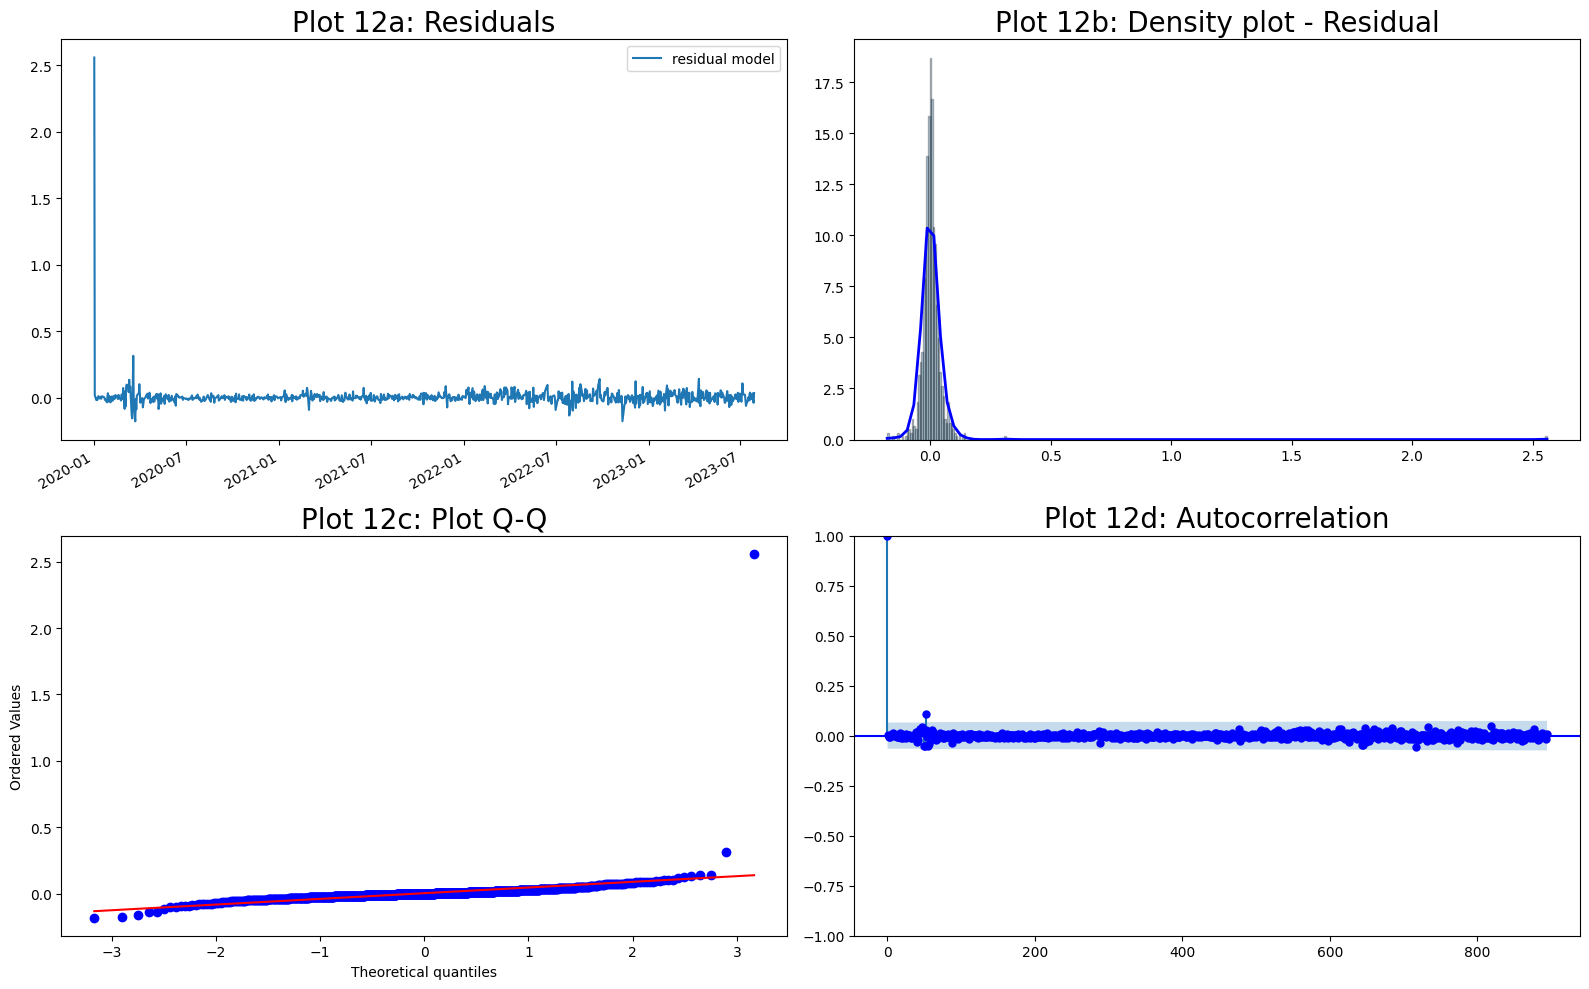

In [66]:
# extract residuals from the model
residual = pd.DataFrame(data=arimax_model.resid, columns=['residual model'])

fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(16,10))

# Residual Plot
residual.plot(ax=axs[0,0])
axs[0,0].set_title('Plot 12a: Residuals', fontsize=20)

# Density
# plot the hist
axs[0,1].hist(
    residual, bins='auto', density=True, alpha=0.30, edgecolor='black')
# plot density curve
kde = stats.gaussian_kde(residual['residual model'])
x_range = np.linspace(min(residual['residual model']), max(residual['residual model']), 100)
axs[0,1].plot(x_range, kde(x_range), linewidth=2, color='blue')
axs[0,1].set_title("Plot 12b: Density plot - Residual", fontsize=20)

# Q-Q plot
stats.probplot(residual["residual model"], dist="norm", plot=axs[1,0])
axs[1,0].set_title('Plot 12c: Plot Q-Q', fontsize=20)

# ACF plot
plot_acf(residual,  lags=len(residual)-1, ax=axs[1,1],color="blue")
axs[1,1].set_title("Plot 12d: Autocorrelation", fontsize=20)

plt.tight_layout()
plt.show()
 

Confirmed by Ljung-Box and Box-Pierce tests and visualizations (see above plots) that in-sample errors/residuals from the model are random white noise (normal IID)

In [67]:
# visualize forecasts and validation set
fig = go.Figure()

# Forecasts
fig.add_trace(go.Scatter(
    x=y_pred.index, 
    y=y_pred[y_pred.columns[0]], 
    mode='lines', 
    name='Forecasts on Validation Set',
    line=dict(color='blue')
    
))

# Training/Fitting Set
fig.add_trace(go.Scatter(
    x=df.index, 
    y=df['OBMMIC30YF'], 
    mode='lines', 
    name='Training/Fitting Set',
    line=dict(color='green')
))

# Validation Set
fig.add_trace(go.Scatter(
    x=X_val.index, 
    y=df['OBMMIC30YF'].loc[X_val.index], 
    mode='lines', 
    name='Validation Set',
    line=dict(color='red')
))

# Validation Set
fig.add_trace(go.Scatter(
    x=X_val.index, 
    y=y_pred[y_pred.columns[0]] - df['OBMMIC30YF'].loc[X_val.index], 
    mode='lines', 
    name='Forecast - Validation Set Spread',
    line=dict(color='brown')
))

fig.update_layout(title={'text':'Plot 13: ARIMAX(2,1,2) Forecasts on 30-Yr Fixed Mortgage Index',
                            'font': dict(size=20)}, 
                            xaxis_title='Daily Time Index', 
                            yaxis_title='% Rate')

fig.update_xaxes(title_font=dict(size=20))
fig.update_yaxes(title_font=dict(size=20))

fig.show()

In [68]:
# ARIMAX(2,1,2) accuracy metrics
arimax_am = round(accuracy_metrics(df['OBMMIC30YF'].loc[X_val.index], y_pred[y_pred.columns[0]])*100, 3)
arimax_am.columns = ['ARIMAX Accuracy %']
arimax_am

,ARIMAX Accuracy %
MAE,15.981
RMSE,19.668
MAPE,231.755
SMAPE,231.446
MdAPE,189.475
GMRAE,1.713


<span style="font-size: 20px">(4) Compare Forecast Accuracy</span>

In [69]:
# conslidate 
summary_accuracy_df = pd.concat([arimax_am, arima_am], axis=1)
summary_accuracy_df['% Difference'] = round( 100*(summary_accuracy_df['ARIMAX Accuracy %'] - summary_accuracy_df['ARIMA Accuracy %'])/summary_accuracy_df['ARIMA Accuracy %'], 3)

summary_accuracy_df

,ARIMAX Accuracy %,ARIMA Accuracy %,% Difference
MAE,15.981,30.287,-47.235
RMSE,19.668,39.407,-50.090
MAPE,231.755,439.836,-47.309
SMAPE,231.446,439.201,-47.303
MdAPE,189.475,324.772,-41.659
GMRAE,1.713,2.478,-30.872


In [70]:
# average % difference
summary_accuracy_df['% Difference'].mean()*(-1)

44.078

As shown on the above summary of accuracy metrics, there has been an average of around 44% improvement in forecasting accuracy from ARIMA to ARIMAX model with the Root-Mean Squared Error being improved the most at about 50%.

Final Notes: In future implementations, it may be worth exploring other methods and models such as Nelson-Siegel, 2-factor Vasicek,  and in Machine Learning domain: Principal Component Regression (PCR) and Recurrent Neural Networks (RNN).

Feedback

- more concise 

- briefly describe the EDA (do bullet points)

- meat of the presentation should be the model and its results

- 10YR AND 2YR are actually correlated

===========
- vendors

- predicting index rates

- improve efficiency

- risk tools

- PSA - VANILLA cpr

<span style="font-size: 20px">==================== END OF SUBMITTED PROJECT ====================</span>

*

<span style="font-size: 20px">Recurrent Neural Networks Implementation</span>

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Load and preprocess data
df = pd.read_csv(r"C:\Users\jpkdu\Documents\Amerihome - Financial Engr Project\OBMMIC30YF_data.csv", 
                 parse_dates=['DATE'], dayfirst=True)
df['OBMMIC30YF'] = pd.to_numeric(df['OBMMIC30YF'], errors='coerce')
df = df.dropna()

# Normalize data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df[['OBMMIC30YF']])


# Create sequences with 10-day window
# this transforms the dataset into a formatted numpy array as input to RNN
# RNN only takes in a specific format of numpy array as input
def create_sequences(data, window_size):
    X, y = [], []
    for i in range(len(data)-window_size):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size])
    return np.array(X), np.array(y)

window_size = 10
X, y = create_sequences(scaled_data, window_size)

# Split dataset (80% train, 20% validation)
train_size = int(0.8 * len(X))
X_train, X_val = X[:train_size], X[train_size:]
y_train, y_val = y[:train_size], y[train_size:]

# Train model ONLY on training set
history = model.fit(X_train, y_train, 
                    epochs=1, 
                    batch_size=1, 
                    #validation_data=(X_val, y_val),
                    verbose=1)

# Make predictions ONLY on validation set
val_predictions = model.predict(X_val)
val_predictions_inv = scaler.inverse_transform(val_predictions)
y_val_inv = scaler.inverse_transform(y_val)

# Calculate validation metrics
print("\nValidation Metrics:")
print(f"MAE: {mean_absolute_error(y_val_inv, val_predictions_inv):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_val_inv, val_predictions_inv)):.4f}")
print(f"R²: {r2_score(y_val_inv, val_predictions_inv):.4f}")

# Plot validation comparison
val_dates = df['DATE'][window_size+train_size:].values

plt.figure(figsize=(12,6))
plt.plot(df['DATE'][window_size:], scaler.inverse_transform(y), label='Actual', color='blue')
plt.plot(df['DATE'][window_size:window_size+train_size], 
         scaler.inverse_transform(y_train), 
         label='Training Data', color='green')
plt.plot(val_dates, val_predictions_inv, 
         label='Validation Forecast', color='red', linestyle='--')
plt.title('Validation Set Forecasting')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.show()


Pytorch RNN

Univariate Case

In [176]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Load and preprocess data - UNIVARIATE
df = pd.read_csv(r"C:\Users\jpkdu\Documents\Amerihome - Financial Engr Project\OBMMIC30YF_data.csv", 
                 parse_dates=['DATE'], dayfirst=True)
df['OBMMIC30YF'] = pd.to_numeric(df['OBMMIC30YF'], errors='coerce')
df = df.dropna()

# Normalize data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df[['OBMMIC30YF']])


In [191]:
df

,DATE,OBMMIC30YF
0,2019-12-27,3.933
1,2019-12-30,3.952
2,2019-12-31,3.927
4,2020-01-02,3.914
5,2020-01-03,3.889
...,...,...
1242,2024-10-01,6.082
1243,2024-10-02,6.132
1244,2024-10-03,6.182
1245,2024-10-04,6.275


In [198]:
def create_sequences(data, seq_length):
    xs, ys = [], []
    for i in range(len(data) - seq_length):
        xs.append(data[i:i+seq_length])
        ys.append(data[i+seq_length])
    return np.array(xs), np.array(ys)

SEQ_LENGTH = 20  # You can adjust this window size
X, y = create_sequences(df.iloc[:,1].values, SEQ_LENGTH)


In [199]:
from sklearn.model_selection import train_test_split
import torch

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, shuffle=False)

# Convert to PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32).unsqueeze(-1)  # (batch, seq, input_size=1)
y_train = torch.tensor(y_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32).unsqueeze(-1)
y_test = torch.tensor(y_test, dtype=torch.float32)


In [205]:
import torch.nn as nn

class BasicRNN(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=1):
        super(BasicRNN, self).__init__()
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)
    def forward(self, x):
        out, _ = self.rnn(x)
        out = out[:, -1, :]  # Take output from the last time step
        return self.fc(out)
        
model = BasicRNN()


In [206]:
import torch.optim as optim

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)
EPOCHS = 100

for epoch in range(EPOCHS):
    model.train()
    output = model(X_train)
    loss = criterion(output.squeeze(), y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{EPOCHS}], Loss: {loss.item():.4f}")


Epoch [10/100], Loss: 2.8635
Epoch [20/100], Loss: 2.3107
Epoch [30/100], Loss: 1.5936
Epoch [40/100], Loss: 0.1074
Epoch [50/100], Loss: 0.0401
Epoch [60/100], Loss: 0.0193
Epoch [70/100], Loss: 0.0069
Epoch [80/100], Loss: 0.0062
Epoch [90/100], Loss: 0.0064
Epoch [100/100], Loss: 0.0058


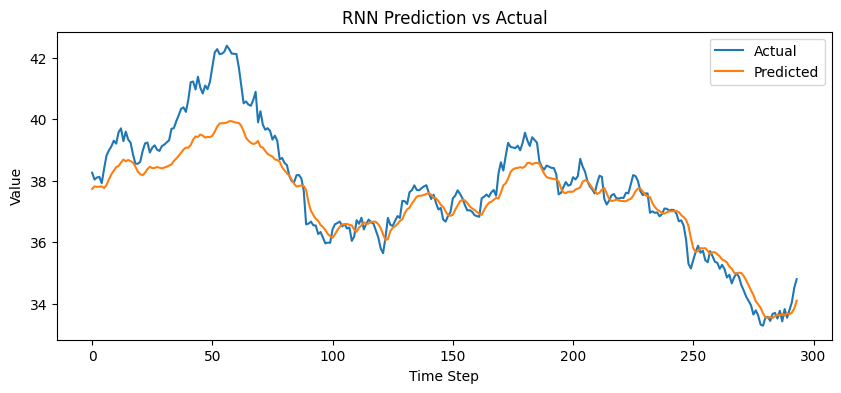

In [207]:
model.eval()
with torch.no_grad():
    predictions = model(X_test).squeeze().numpy()
    # Inverse transform to original scale
    y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1))
    predictions_inv = scaler.inverse_transform(predictions.reshape(-1, 1))

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 4))
plt.plot(y_test_inv, label='Actual')
plt.plot(predictions_inv, label='Predicted')
plt.title("RNN Prediction vs Actual")
plt.xlabel("Time Step")
plt.ylabel("Value")
plt.legend()
plt.show()


daily treasury rates analysis

In [435]:
daily_treas_rates_df = pd.read_csv(r"C:\Users\jpkdu\Downloads\daily-treasury-rates.csv", parse_dates=['Date'])
daily_treas_rates_df = daily_treas_rates_df.set_index('Date')

daily_mortg_index_df = pd.read_csv(r"C:\Users\jpkdu\Downloads\OBMMIC30YF.csv", parse_dates=['observation_date'])
daily_mortg_index_df.columns = ['Date', daily_mortg_index_df.columns[1]]
daily_mortg_index_df = daily_mortg_index_df.set_index('Date')

# removes 1.5 Month
daily_treas_rates_df = daily_treas_rates_df[[x for x in daily_treas_rates_df.columns if x!='1.5 Month']]

consolidate_df = pd.concat([daily_treas_rates_df,daily_mortg_index_df.loc[daily_treas_rates_df.index[1:]]], axis=1)
consolidate_df

,1 Mo,2 Mo,3 Mo,4 Mo,6 Mo,1 Yr,2 Yr,3 Yr,5 Yr,7 Yr,10 Yr,20 Yr,30 Yr,OBMMIC30YF
Date,,,,,,,,,,,,,,
2025-01-02,4.45,4.36,4.36,4.31,4.25,4.17,4.25,4.29,4.38,4.47,4.57,4.86,4.79,6.876
2025-01-03,4.44,4.35,4.34,4.31,4.25,4.18,4.28,4.32,4.41,4.51,4.60,4.88,4.82,6.900
2025-01-06,4.43,4.36,4.35,4.31,4.24,4.17,4.28,4.30,4.42,4.52,4.62,4.91,4.85,6.875
2025-01-07,4.42,4.35,4.35,4.31,4.24,4.19,4.30,4.33,4.46,4.57,4.67,4.97,4.91,6.943
2025-01-08,4.41,4.34,4.35,4.31,4.25,4.19,4.28,4.31,4.45,4.56,4.67,4.97,4.91,6.960
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-05-08,4.37,4.35,4.34,4.40,4.28,4.05,3.90,3.85,4.00,4.18,4.37,4.86,4.83,6.776
2025-05-09,4.37,4.34,4.34,4.40,4.28,4.05,3.88,3.85,4.00,4.18,4.37,4.86,4.83,6.781
2025-05-12,4.38,4.36,4.42,4.45,4.29,4.11,3.98,3.97,4.09,4.27,4.45,4.92,4.89,6.812


In [436]:
# Plot all columns using the DataFrame index as x-axis
fig = px.line(consolidate_df, x=consolidate_df.index, y=consolidate_df.columns, width=1000, height=500)
fig.update_layout(
    xaxis_title="Daily Time Index",
    yaxis_title="% Rate",
    legend_title_text="Legend",
    title={'text':'Daily Treasury Yield Curves ',
           'font': dict(size=23)} 
)

fig.update_xaxes(title_font=dict(size=20))
fig.update_yaxes(title_font=dict(size=20))

fig.show()

In [351]:
# visualize annual yield curves

daily_treas_rates_df['month'] = daily_treas_rates_df.index.month # create a 'month' column 

maturities = daily_treas_rates_df.columns.drop(['month']) # available maturities in the dataset

fig = go.Figure()
for month in sorted(daily_treas_rates_df['month'].unique()):
    avg_yields = daily_treas_rates_df[daily_treas_rates_df['month'] == month][maturities].mean()
    fig.add_trace(go.Scatter(x=maturities, y=avg_yields, mode='lines+markers', name=str(month)))

fig.update_layout(
    title={'text': 'Average Treasury Yield Curves per month',
           'font': dict(size=23)}, 
    xaxis_title='Maturity',
    yaxis_title='Yield (%)',
    height=500,
    width=1000
)

fig.update_xaxes(title_font=dict(size=20))
fig.update_yaxes(title_font=dict(size=20))

fig.show()